# Speed Dating Analysis — What Makes People Want a Second Date?

This dataset covers **21 speed dating events** run at Columbia University between 2002 and 2004.
Each row represents one 4-minute encounter between two participants (8,378 encounters total, 551 unique participants).
Participants rated each other on six attributes — attractiveness, sincerity, intelligence, fun, ambition, and shared interests — and indicated whether they wanted a second date. A **match** occurred when both said yes.

**Five research questions:**
1. What are the least desirable attributes in a partner? Does this differ by gender?
2. How important do people think attractiveness is in potential mate selection vs. its real impact?
3. Are shared interests more important than a shared racial background?
4. Can people accurately predict their own perceived value in the dating market?
5. Is it better to be someone's first speed date of the night or their last?

Source: Speed Dating Experiment dataset (Fisman, Iyengar et al., Columbia University, 2002-2004).

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

os.makedirs('plots', exist_ok=True)

In [2]:
df = pd.read_csv("data/input/Speed_Dating_Data.csv", encoding="latin-1")
print(f"Raw dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

Raw dataset: 8,378 rows x 195 columns


## Dataset Overview

In [3]:
# Categorical variable mappings (from Speed Dating Data Key)
MAPPINGS = {
    'gender': {0: 'Women', 1: 'Men'},
    'field_cd': {
        1: 'Law',
        2: 'Math',
        3: 'Social Science, Psychologist',
        4: 'Medical Science, Pharmaceuticals, and Bio Tech',
        5: 'Engineering',
        6: 'English/Creative Writing/Journalism',
        7: 'History/Religion/Philosophy',
        8: 'Business/Econ/Finance',
        9: 'Education, Academia',
        10: 'Biological Sciences/Chemistry/Physics',
        11: 'Social Work',
        12: 'Undergrad/undecided',
        13: 'Political Science/International Affairs',
        14: 'Film',
        15: 'Fine Arts/Arts Administration',
        16: 'Languages',
        17: 'Architecture',
        18: 'Other'
    },
}

In [4]:
total_rows = df.shape[0]
unique_participants = df['iid'].nunique()
unique_waves = df['wave'].nunique()
yes_rate = df['dec'].mean()
match_rate = df['match'].mean()

gender_counts = df.groupby('gender')['iid'].nunique()

print("=== Dataset Overview ===")
print(f"Total encounters : {total_rows:,}")
print(f"Unique participants: {unique_participants}")
print(f"Unique waves       : {unique_waves}")
print(f"Overall 'yes' rate : {yes_rate:.1%}")
print(f"Overall match rate : {match_rate:.1%}")
print()
print("Gender split (unique participants):")
for gender_code, count in gender_counts.items():
    label = MAPPINGS['gender'].get(gender_code, str(gender_code))
    print(f"  {label}: {count}")

=== Dataset Overview ===
Total encounters : 8,378
Unique participants: 551
Unique waves       : 21
Overall 'yes' rate : 42.0%
Overall match rate : 16.5%

Gender split (unique participants):
  Women: 274
  Men: 277


### Missing Values Analysis

Columns with missing values: 182 / 195

Top 20 columns by NaN rate:

num_in_3    92.0
numdat_3    82.1
expnum      78.5
sinc7_2     76.7
amb7_2      76.7
shar7_2     76.4
attr7_2     76.3
fun7_2      76.3
intel7_2    76.3
fun5_3      75.9
amb5_3      75.9
shar2_3     75.9
attr5_3     75.9
amb7_3      75.9
shar7_3     75.9
sinc5_3     75.9
sinc7_3     75.9
intel7_3    75.9
fun7_3      75.9
attr7_3     75.9


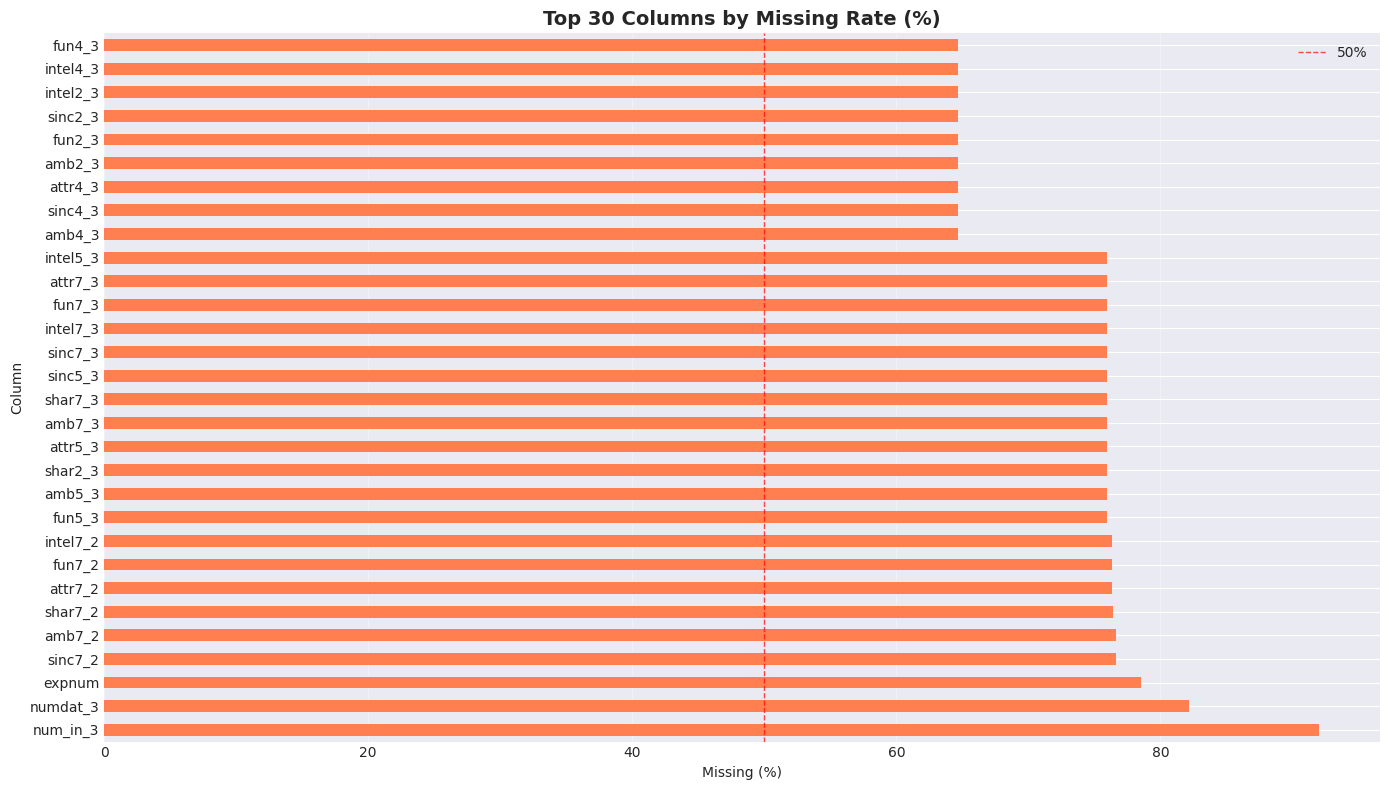

In [5]:
# Missing values analysis on the raw dataset (before cleaning)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print(f"Columns with missing values: {len(missing_pct)} / {df.shape[1]}")
print("\nTop 20 columns by NaN rate:\n")
print(missing_pct.head(20).round(1).to_string())

# Horizontal bar chart of top 30 columns
fig, ax = plt.subplots(figsize=(14, 8))
missing_pct.head(30).plot(kind='barh', ax=ax, color='coral')
ax.set_title('Top 30 Columns by Missing Rate (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Missing (%)')
ax.set_ylabel('Column')
ax.axvline(50, color='red', linestyle='--', linewidth=1, alpha=0.7, label='50%')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/01_nan_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Expected output

![Bar chart: top 30 columns with most NaN values](plots/01_nan_distribution.png)

Missing values fall into four structural categories:

1. **Time 3 columns** (~52.6% missing): legitimate — only 47.4% of participants completed the follow-up survey 3-4 weeks after the event.
2. **Time 2 columns** (~11% missing): legitimate — ~89% response rate for the post-event survey (day after).
3. **Demographic columns** (career, field, zipcode): partial non-response to the intake questionnaire.
4. **By-design columns** (positin1, undergra): only collected for specific waves or subgroups.

In [6]:
ATTR_PREFIXES = ('attr', 'sinc', 'intel', 'fun', 'amb', 'shar')

time2_cols = [
    c for c in df.columns
    if c.endswith('_2') and any(c.startswith(p) for p in ATTR_PREFIXES)
]
time3_cols = [
    c for c in df.columns
    if c.endswith('_3') and any(c.startswith(p) for p in ATTR_PREFIXES)
]

time2_respondents = df[time2_cols].notna().any(axis=1).sum()
time3_respondents = df[time3_cols].notna().any(axis=1).sum()
n_rows = len(df)

print("=== Follow-up Response Rates ===")
print(f"Time 2 (day after):       {time2_respondents:,} / {n_rows:,} ({time2_respondents / n_rows:.1%})")
print(f"Time 3 (3-4 weeks after): {time3_respondents:,} / {n_rows:,} ({time3_respondents / n_rows:.1%})")

=== Follow-up Response Rates ===
Time 2 (day after):       7,463 / 8,378 (89.1%)
Time 3 (3-4 weeks after): 3,974 / 8,378 (47.4%)


### Time 2 Selection Bias Check

With ~11% non-response at Time 2, we verify whether non-respondents differ systematically from respondents.

=== Time 2 Respondents vs Non-respondents ===

                Respondents  Non-respondents
n participants      485.000           66.000
mean dec              0.438            0.354
mean dec_o            0.427            0.412
mean match            0.172            0.145


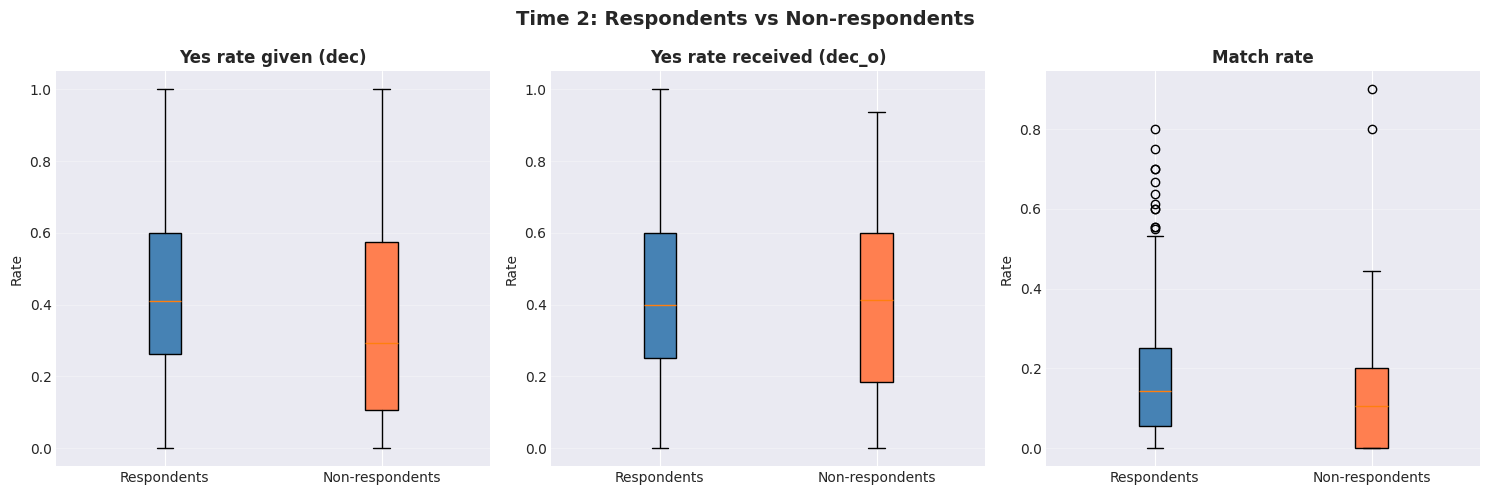

In [7]:
df = df.copy()

# Identify Time 2 respondents using attribute columns with _2 suffix
t2_attr_cols = [
    c for c in df.columns
    if c.endswith('_2') and any(c.startswith(p) for p in ATTR_PREFIXES)
]
df['responded_time2'] = df[t2_attr_cols].notna().any(axis=1)

# Aggregate at participant level
participant_t2 = df.groupby('iid').agg({
    'dec': 'mean',
    'dec_o': 'mean',
    'match': 'mean',
    'responded_time2': 'first',
}).reset_index()

respondents = participant_t2[participant_t2['responded_time2']]
non_respondents = participant_t2[~participant_t2['responded_time2']]

# Comparison table
comparison = pd.DataFrame({
    'Respondents': [
        len(respondents),
        respondents['dec'].mean(),
        respondents['dec_o'].mean(),
        respondents['match'].mean(),
    ],
    'Non-respondents': [
        len(non_respondents),
        non_respondents['dec'].mean(),
        non_respondents['dec_o'].mean(),
        non_respondents['match'].mean(),
    ],
}, index=['n participants', 'mean dec', 'mean dec_o', 'mean match'])

print("=== Time 2 Respondents vs Non-respondents ===\n")
print(comparison.round(3))

# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, (metric, label) in enumerate([
    ('dec', 'Yes rate given (dec)'),
    ('dec_o', 'Yes rate received (dec_o)'),
    ('match', 'Match rate'),
]):
    data_resp = respondents[metric].dropna()
    data_non = non_respondents[metric].dropna()
    bp = axes[idx].boxplot(
        [data_resp, data_non],
        tick_labels=['Respondents', 'Non-respondents'],
        patch_artist=True,
    )
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('coral')
    axes[idx].set_ylabel('Rate')
    axes[idx].set_title(label, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Time 2: Respondents vs Non-respondents', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/02_time2_response_bias.png', dpi=150, bbox_inches='tight')
plt.show()

df.drop(columns=['responded_time2'], inplace=True)

### Expected output

![Bar chart: Time2 respondents vs non-respondents](plots/02_time2_response_bias.png)

Non-response (~11%) introduces limited systematic bias. `dec_o` (decision received from partners) is similar across groups (small gap), but `dec` (own selectivity) shows an 8.4 pp gap (0.438 vs 0.354) — non-respondents are slightly more selective. The match rate gap is small. Time 2 data is usable for relative comparisons; the `dec` gap is noted as a caveat.

In [8]:
key_numeric = [
    "age", "attr_o", "sinc_o", "intel_o", "fun_o", "amb_o", "shar_o",
    "attr", "sinc", "intel", "fun", "amb", "shar",
    "like", "prob", "int_corr", "mn_sat", "order",
]
existing = [c for c in key_numeric if c in df.columns]
df[existing].describe().round(2)

,age,attr_o,sinc_o,intel_o,fun_o,amb_o,shar_o,attr,sinc,intel,fun,amb,shar,like,prob,int_corr,order
count,8283.00,8166.00,8091.00,8072.00,8018.00,7656.00,7302.00,8176.00,8101.00,8082.00,8028.00,7666.00,7311.00,8138.00,8069.00,8220.00,8378.00
mean,26.36,6.19,7.18,7.37,6.40,6.78,5.47,6.19,7.18,7.37,6.40,6.78,5.47,6.13,5.21,0.20,8.93
std,3.57,1.95,1.74,1.55,1.95,1.79,2.16,1.95,1.74,1.55,1.95,1.79,2.16,1.84,2.13,0.30,5.48
min,18.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.83,1.00
25%,24.00,5.00,6.00,6.00,5.00,6.00,4.00,5.00,6.00,6.00,5.00,6.00,4.00,5.00,4.00,-0.02,4.00
50%,26.00,6.00,7.00,7.00,7.00,7.00,6.00,6.00,7.00,7.00,7.00,7.00,6.00,6.00,5.00,0.21,8.00
75%,28.00,8.00,8.00,8.00,8.00,8.00,7.00,8.00,8.00,8.00,8.00,8.00,7.00,7.00,7.00,0.43,13.00
max,55.00,10.50,10.00,10.00,11.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,0.91,22.00


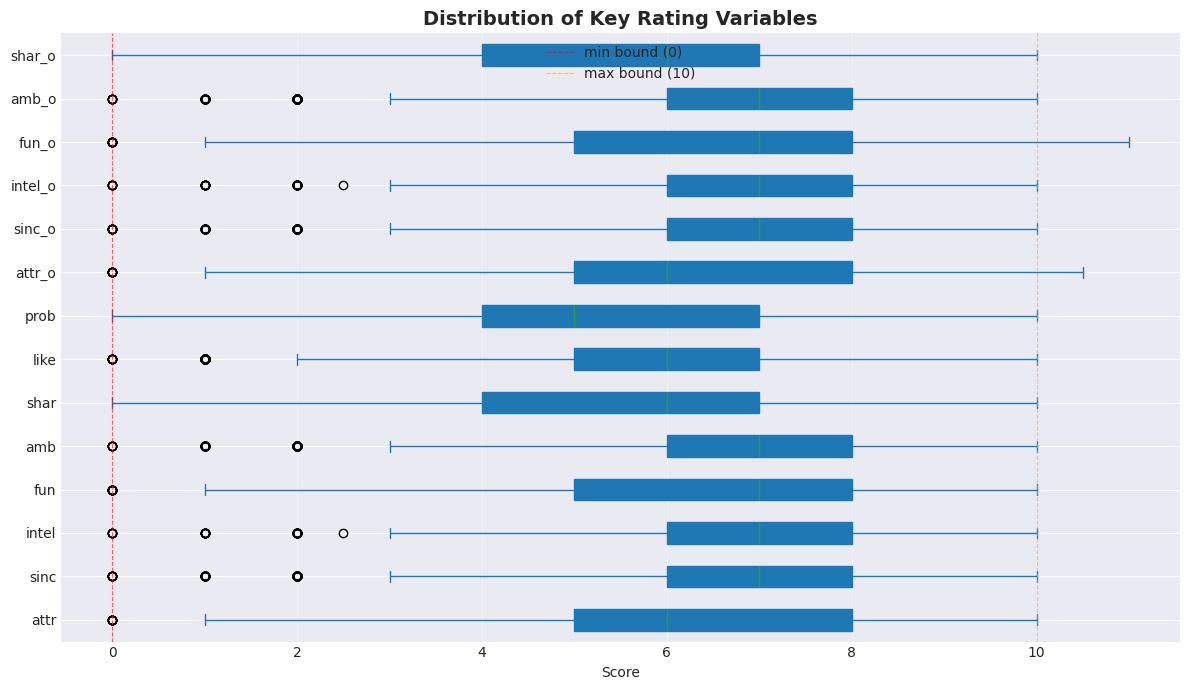

Columns with values outside [0, 10]:
  attr_o: min=0.0, max=10.5
  fun_o: min=0.0, max=11.0


In [9]:
rating_cols = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar',
               'like', 'prob', 'attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o', 'shar_o']

fig, ax = plt.subplots(figsize=(12, 7))
df[rating_cols].plot(kind='box', vert=False, ax=ax, patch_artist=True)
ax.set_title('Distribution of Key Rating Variables', fontsize=14, fontweight='bold')
ax.set_xlabel('Score')
ax.axvline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='min bound (0)')
ax.axvline(10, color='orange', linestyle='--', linewidth=0.8, alpha=0.6, label='max bound (10)')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/03_attribute_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Check for values outside expected [0, 10] range
out_of_range = {}
for col in rating_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_min < 0 or col_max > 10:
        out_of_range[col] = {'min': col_min, 'max': col_max}

if out_of_range:
    print("Columns with values outside [0, 10]:")
    for col, bounds in out_of_range.items():
        print(f"  {col}: min={bounds['min']}, max={bounds['max']}")
else:
    print("All columns within [0, 10] range.")

### Expected output

![Boxplot: distributions of key rating variables](plots/03_attribute_distributions.png)

- Rating variables are bounded by the survey instrument (1-10 scale for partner evaluations during the date).
- A few values slightly exceed the 1-10 range (`fun_o` max=11.0, `attr_o` max=10.5): these are per-encounter averages computed from multiple partner ratings, so fractional values above 10 are averaging artifacts, not data entry errors.
- All values are within plausible human response range; no extreme contamination is present.
- No outlier removal is applied: trimming bounded-scale data would bias the distribution without correcting any real error.

In [10]:
# --- 100-point validation ---
WAVES_100PT = [1, 2, 3, 4, 5, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]

attribute_series = [
    ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1'],
    ['attr2_1', 'sinc2_1', 'intel2_1', 'fun2_1', 'amb2_1', 'shar2_1'],
    ['attr4_1', 'sinc4_1', 'intel4_1', 'fun4_1', 'amb4_1', 'shar4_1'],
    ['attr1_2', 'sinc1_2', 'intel1_2', 'fun1_2', 'amb1_2', 'shar1_2'],
    ['attr2_2', 'sinc2_2', 'intel2_2', 'fun2_2', 'amb2_2', 'shar2_2'],
    ['attr4_2', 'sinc4_2', 'intel4_2', 'fun4_2', 'amb4_2', 'shar4_2'],
    ['attr7_2', 'sinc7_2', 'intel7_2', 'fun7_2', 'amb7_2', 'shar7_2'],
    ['attr1_3', 'sinc1_3', 'intel1_3', 'fun1_3', 'amb1_3', 'shar1_3'],
    ['attr7_3', 'sinc7_3', 'intel7_3', 'fun7_3', 'amb7_3', 'shar7_3'],
]

def validate_100pt_sum(row, columns, tolerance=0.1):  # tolerance for float precision (integer data, any value < 1 gives identical results)
    values = row[columns]
    if values.isna().all():
        return np.nan
    if values.isna().any():
        return False
    return abs(values.sum() - 100) <= tolerance

mask_100pt = df['wave'].isin(WAVES_100PT)

rows_to_drop = set()
for _, columns in zip(
    ['attr1_1', 'attr2_1', 'attr4_1', 'attr1_2', 'attr2_2', 'attr4_2', 'attr7_2', 'attr1_3', 'attr7_3'],
    attribute_series
):
    validation = df.loc[mask_100pt].apply(lambda row: validate_100pt_sum(row, columns), axis=1)
    invalid_indices = validation[validation == False].index
    rows_to_drop.update(invalid_indices)

df = df.drop(index=list(rows_to_drop))
print(f"100-point validation: {len(rows_to_drop):,} invalid rows dropped")

# --- Scale normalization (waves 6-9: 1-10 -> percentage) ---
WAVES_6_9 = [6, 7, 8, 9]
mask_1_10 = df['wave'].isin(WAVES_6_9)

series_to_normalize = {
    'attr4_1': ['attr4_1', 'sinc4_1', 'intel4_1', 'fun4_1', 'amb4_1', 'shar4_1'],
    'attr4_2': ['attr4_2', 'sinc4_2', 'intel4_2', 'fun4_2', 'amb4_2', 'shar4_2'],
    'attr4_3': ['attr4_3', 'sinc4_3', 'intel4_3', 'fun4_3', 'amb4_3', 'shar4_3'],
    'attr2_3': ['attr2_3', 'sinc2_3', 'intel2_3', 'fun2_3', 'amb2_3', 'shar2_3'],
}

for series_name, cols in series_to_normalize.items():
    existing_cols = [c for c in cols if c in df.columns]
    rows_mask = mask_1_10 & df[existing_cols].notna().any(axis=1)
    if rows_mask.sum() == 0:
        continue
    row_sums = df.loc[rows_mask, existing_cols].sum(axis=1).replace(0, np.nan)
    for col in existing_cols:
        df.loc[rows_mask, col] = df.loc[rows_mask, col] / row_sums * 100

print(f"Scale normalization: waves {WAVES_6_9} converted from 1-10 to percentages")
print(f"\nClean dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Unique participants: {df['iid'].nunique()}")
df = df.copy()

100-point validation: 1,506 invalid rows dropped
Scale normalization: waves [6, 7, 8, 9] converted from 1-10 to percentages

Clean dataset: 6,872 rows x 195 columns
Unique participants: 455


### Bias check: 100-point allocation filter

Before proceeding, we verify that the rows dropped by the 100-point validation do not introduce systematic bias in key outcome variables.

=== 100-point filter: Retained vs Dropped ===

                   Retained   Dropped
n rows             6872.000  1506.000
mean dec              0.430     0.375
mean match            0.164     0.168
mean gender (1=M)     0.507     0.469


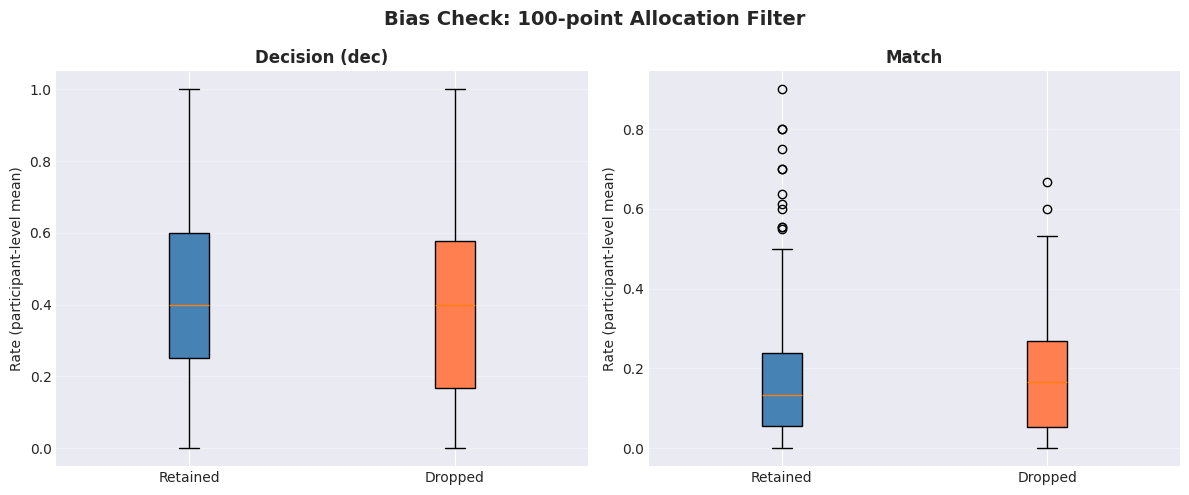

In [11]:
# Reload raw data to recover dropped rows for comparison
df_raw_check = pd.read_csv("data/input/Speed_Dating_Data.csv", encoding="latin-1")
dropped_mask = df_raw_check.index.isin(rows_to_drop)

retained = df_raw_check[~dropped_mask]
dropped = df_raw_check[dropped_mask]

# Comparison table on key outcome variables
comparison_100pt = pd.DataFrame({
    'Retained': [
        len(retained),
        retained['dec'].mean(),
        retained['match'].mean(),
        retained['gender'].mean(),
    ],
    'Dropped': [
        len(dropped),
        dropped['dec'].mean(),
        dropped['match'].mean(),
        dropped['gender'].mean(),
    ],
}, index=['n rows', 'mean dec', 'mean match', 'mean gender (1=M)'])

print(f"=== 100-point filter: Retained vs Dropped ===\n")
print(comparison_100pt.round(3))

# Boxplots comparing dec and match distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (col, label) in enumerate([
    ('dec', 'Decision (dec)'),
    ('match', 'Match'),
]):
    # Aggregate at participant level to avoid inflated sample sizes
    retained_by_iid = retained.groupby('iid')[col].mean()
    dropped_by_iid = dropped.groupby('iid')[col].mean()

    bp = axes[idx].boxplot(
        [retained_by_iid.dropna(), dropped_by_iid.dropna()],
        tick_labels=['Retained', 'Dropped'],
        patch_artist=True,
    )
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('coral')
    axes[idx].set_ylabel('Rate (participant-level mean)')
    axes[idx].set_title(label, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Bias Check: 100-point Allocation Filter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03b_bias_check_100pt.png', dpi=150, bbox_inches='tight')
plt.show()

del df_raw_check, dropped_mask, retained, dropped

### Expected output
![Bias check: 100-point allocation filter](plots/03b_bias_check_100pt.png)

- The comparison table shows modest differences between retained and dropped rows: decision rate is 5.5 pp lower in dropped rows (0.375 vs 0.430), match rate shows a small 0.4 pp gap (0.168 vs 0.164), and gender balance shows a small 3.8 pp gap (dropped rows skew slightly more female: 0.469 vs 0.507). All three gaps are within the same modest range. (pp = percentage points: the difference between two percentages, e.g. 50.7% − 46.9% = 3.8 pp.)
- Boxplots confirm similar distributions at the participant level. The 100-point filter does not introduce major systematic bias in outcome variables.

## Data Cleaning Pipeline

1. **100-point validation** (waves 1-5, 10-21): participants allocated 100 points across 6 attributes. Rows where any series did not sum to 100 (tolerance 0.1) were dropped as data entry errors.
2. **Scale normalization** (waves 6-9): converted from 1-10 independent ratings to percentages (value / row_sum x 100) for cross-wave comparability.
3. **No imputation**: missing values are structural (Time 2 response rate ~89%, Time 3 ~47%), not random. Imputing would fabricate data.

---
## Q1: What Are the Least Desirable Attributes in a Partner? Does It Differ by Gender?

In [12]:
# Attributes and readable names
attr_cols = ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']
attr_names = ['Attractiveness', 'Sincerity', 'Intelligence', 'Fun', 'Ambition', 'Shared Interests']

# Aggregate by participant first to avoid double-counting
participant_prefs = df.groupby(['iid', 'gender'])[attr_cols].first().reset_index()

women_prefs = participant_prefs[participant_prefs['gender'] == 0][attr_cols].mean()
men_prefs = participant_prefs[participant_prefs['gender'] == 1][attr_cols].mean()

preferences_by_gender = pd.DataFrame({
    'Women': women_prefs.values,
    'Men': men_prefs.values
}, index=attr_names)

print("Average attribute importance by gender (out of 100 points):\n")
print(preferences_by_gender.round(1))

Average attribute importance by gender (out of 100 points):

                  Women   Men
Attractiveness     17.5  26.7
Sincerity          18.5  16.7
Intelligence       20.9  19.6
Fun                17.3  17.1
Ambition           13.2   8.7
Shared Interests   12.6  11.2


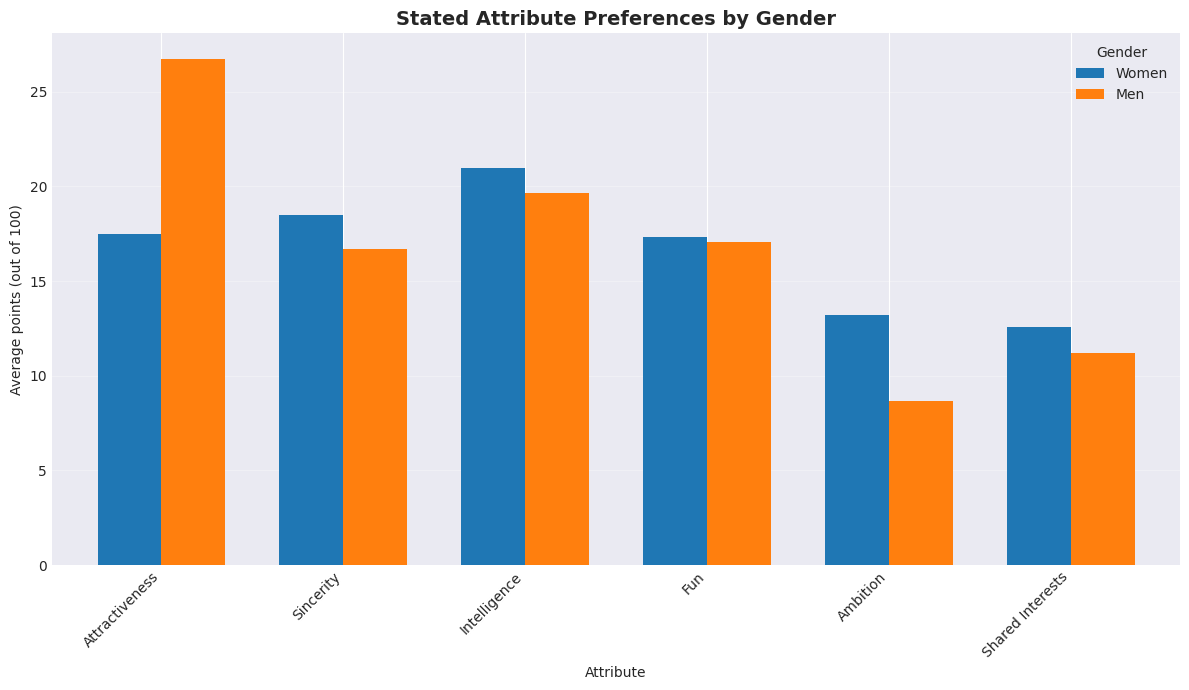

In [13]:
fig, ax = plt.subplots(figsize=(12, 7))
preferences_by_gender.plot(kind='bar', ax=ax, width=0.7)
ax.set_title('Stated Attribute Preferences by Gender', fontsize=14, fontweight='bold')
ax.set_ylabel('Average points (out of 100)')
ax.set_xlabel('Attribute')
ax.set_xticklabels(attr_names, rotation=45, ha='right')
ax.legend(title='Gender')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/04_stated_preferences_gender.png', dpi=150, bbox_inches='tight')
plt.show()

### Expected output

![Bar chart: stated attribute preferences by gender](plots/04_stated_preferences_gender.png)

- Men assign significantly more importance to attractiveness in their stated preferences; women distribute points more evenly across attributes

In [14]:
# Gender differences
preferences_by_gender['Difference (M - F)'] = preferences_by_gender['Men'] - preferences_by_gender['Women']

print("\nDifferences Men - Women:\n")
print(preferences_by_gender[['Difference (M - F)']].sort_values('Difference (M - F)', ascending=False).round(1))


Differences Men - Women:

                  Difference (M - F)
Attractiveness                   9.3
Fun                             -0.2
Intelligence                    -1.3
Shared Interests                -1.4
Sincerity                       -1.8
Ambition                        -4.5


When participants allocate 100 points across six attributes, the **lowest-ranked attribute differs by gender**. For **women**, **Shared Interests** (12.6 pts) is the lowest, just below **Ambition** (13.2 pts). For **men**, the lowest is **Ambition** (8.7 pts), followed by **Shared Interests** (11.2 pts). The pattern that holds across both genders is that Ambition and Shared Interests sit at the bottom of the budget — but the contrast lies in **how strongly men devalue Ambition** (8.7 vs 13.2 for women, a -4.5 pt gap), the second-largest gender difference after attractiveness.

The largest gender gap is on **Attractiveness**: men allocate 26.7 points — their single highest-ranked attribute — versus only 17.5 for women, a difference of 9.3 points. Women spread their budget more evenly and rank **Intelligence** first (20.9 pts), followed by **Sincerity** (18.5 pts). For a second date to happen, these results suggest that looking attractive is the dominant filter for men, while women apply a broader set of criteria with no single attribute dominating.

---
## Q2: How Important Do People Think Attractiveness Is vs. Its Real Impact?

In [15]:
# Stated average importance of attractiveness
perceived_importance = df.groupby('iid')['attr1_1'].first().mean()

print(f"Stated importance of attractiveness: {perceived_importance:.1f} points (out of 100)")

Stated importance of attractiveness: 22.2 points (out of 100)


In [16]:
# Global stated importance (all participants)
global_prefs = df.groupby('iid')[attr_cols].first().mean()
global_prefs.index = attr_names

print("Global stated attribute importance (all participants):\n")
print(global_prefs.sort_values(ascending=False).round(1))

Global stated attribute importance (all participants):

Attractiveness      22.2
Intelligence        20.3
Sincerity           17.6
Fun                 17.2
Shared Interests    11.9
Ambition            10.9
dtype: float64


In [17]:
# Real impact: correlation between attractiveness rating given to partner and decision
attr_rating_cols = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar']

correlations_with_dec = df[attr_rating_cols + ['dec']].corr()['dec'].drop('dec')

correlation_df = pd.DataFrame({
    'Attribute': attr_names,
    'Correlation with decision': correlations_with_dec.values
})

print("\nCorrelations between rated attributes and yes/no decision:\n")
print(correlation_df.sort_values('Correlation with decision', ascending=False).round(3))


Correlations between rated attributes and yes/no decision:

          Attribute  Correlation with decision
0    Attractiveness                      0.483
3               Fun                      0.410
5  Shared Interests                      0.390
2      Intelligence                      0.216
1         Sincerity                      0.209
4          Ambition                      0.183


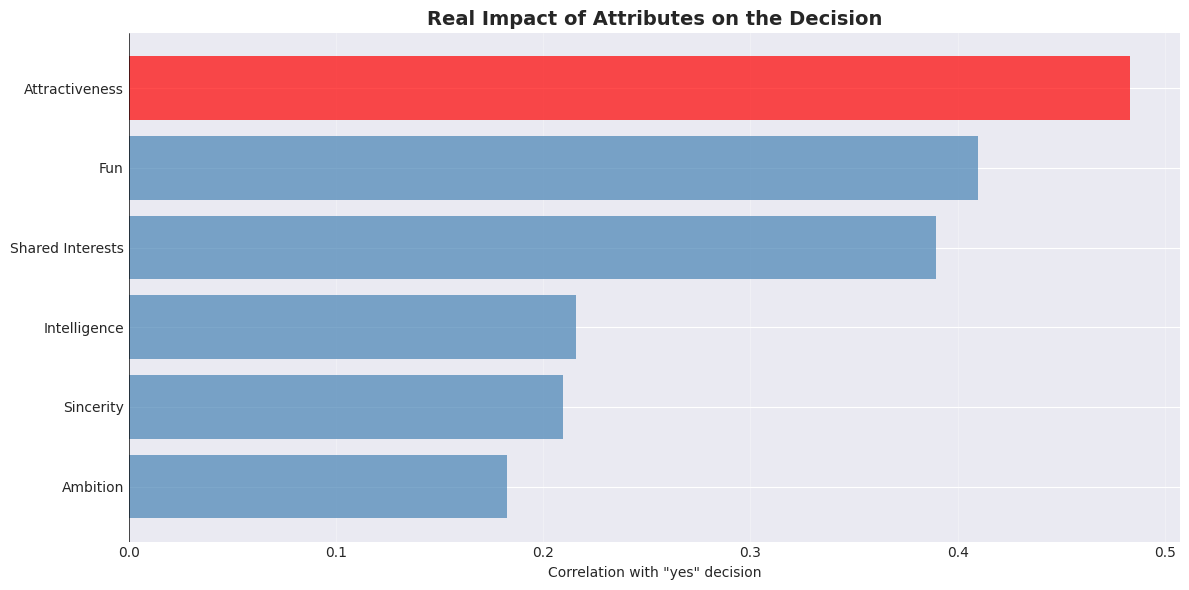

In [18]:
# Visualization: real impact (sorted by correlation)
sorted_corr = correlation_df.sort_values('Correlation with decision')

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['red' if x == 'Attractiveness' else 'steelblue' for x in sorted_corr['Attribute']]
ax.barh(sorted_corr['Attribute'], sorted_corr['Correlation with decision'], color=colors, alpha=0.7)
ax.set_xlabel('Correlation with "yes" decision')
ax.set_title('Real Impact of Attributes on the Decision', fontsize=14, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/05_attribute_impact_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

### Expected output

![Bar chart: real attribute impact on decision (correlation)](plots/05_attribute_impact_correlation.png)

- Attractiveness has by far the strongest correlation with "yes" decisions (r = 0.483), well ahead of fun (r = 0.410) and shared interests (r = 0.390)
- The gap between stated preferences (modest) and revealed behavior (dominant attractiveness) is the key finding

In [19]:
# By gender
women_decisions = df[df['gender'] == 0]
men_decisions = df[df['gender'] == 1]

women_corr = women_decisions[attr_rating_cols + ['dec']].corr()['dec'].drop('dec')
men_corr = men_decisions[attr_rating_cols + ['dec']].corr()['dec'].drop('dec')

corr_by_gender = pd.DataFrame({
    'Women': women_corr.values,
    'Men': men_corr.values
}, index=attr_names)

print("\nCorrelations with decision by gender:\n")
print(corr_by_gender.round(3))


Correlations with decision by gender:

                  Women    Men
Attractiveness    0.436  0.517
Sincerity         0.209  0.211
Intelligence      0.226  0.229
Fun               0.404  0.415
Ambition          0.176  0.220
Shared Interests  0.391  0.390


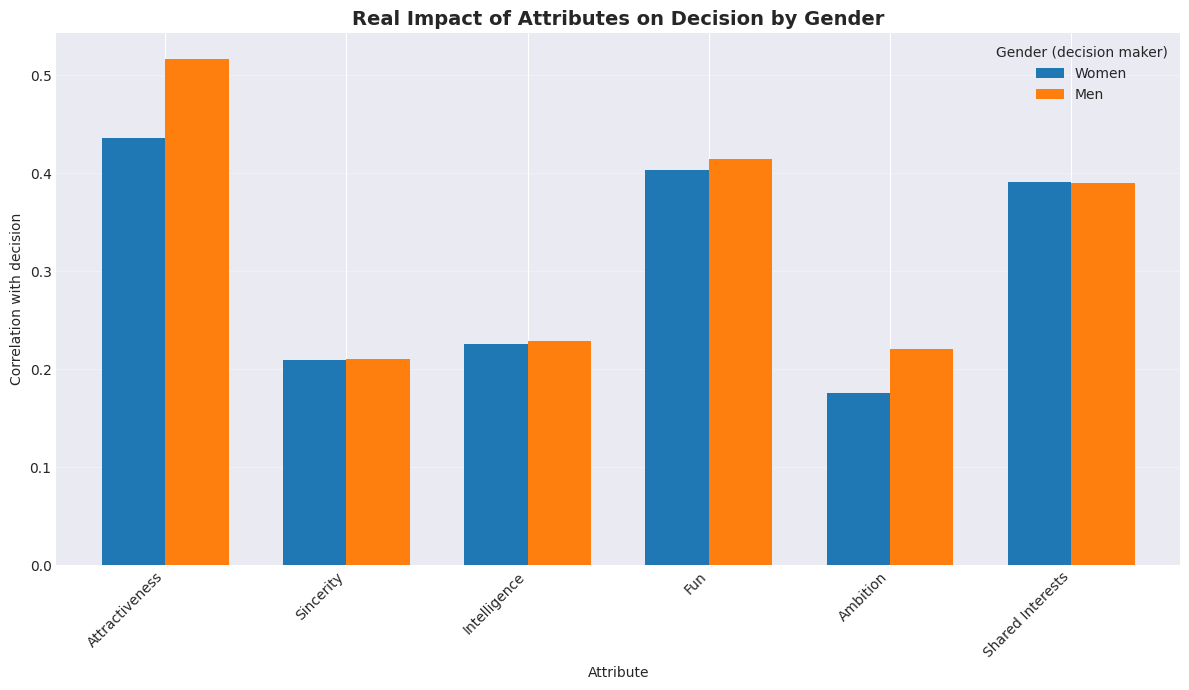

In [20]:
fig, ax = plt.subplots(figsize=(12, 7))
corr_by_gender.plot(kind='bar', ax=ax, width=0.7)
ax.set_title('Real Impact of Attributes on Decision by Gender', fontsize=14, fontweight='bold')
ax.set_ylabel('Correlation with decision')
ax.set_xlabel('Attribute')
ax.set_xticklabels(attr_names, rotation=45, ha='right')
ax.legend(title='Gender (decision maker)')
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/06_attribute_impact_gender.png', dpi=150, bbox_inches='tight')
plt.show()

### Expected output

![Bar chart: real attribute impact by gender](plots/06_attribute_impact_gender.png)

- Both genders reveal attractiveness as the top driver of decisions, contradicting women's stated preference for a balanced profile
- Men's decisions show a slightly stronger attractiveness signal (r = 0.517 vs 0.436 for women)

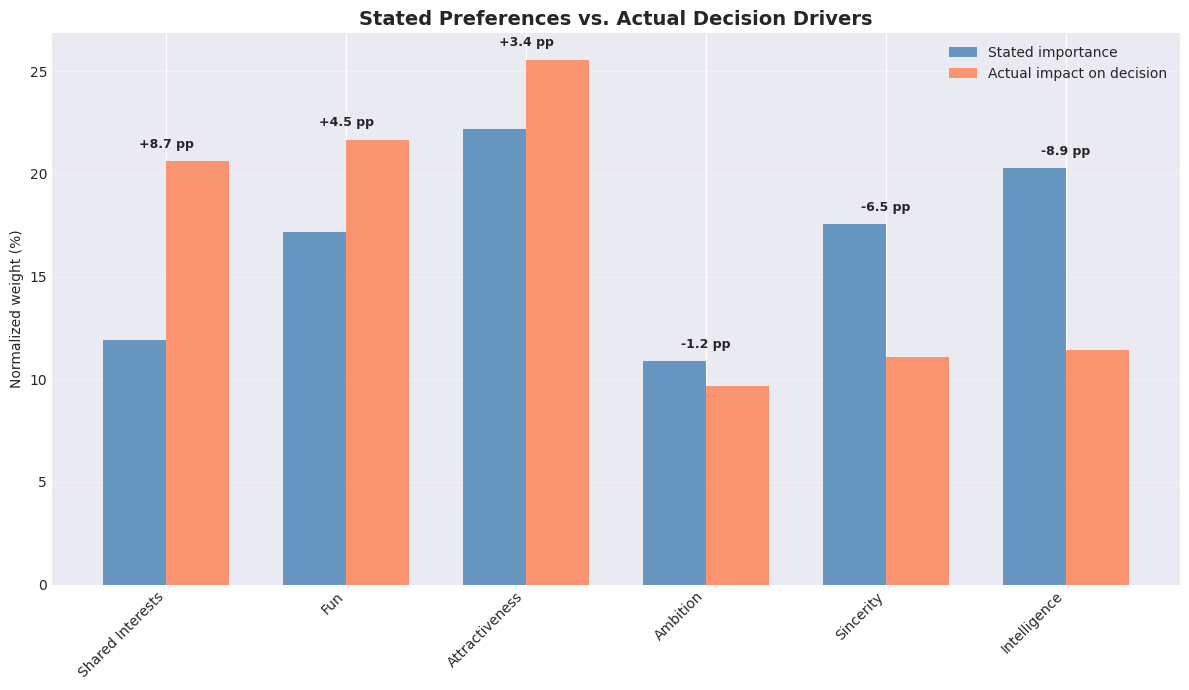

In [21]:
# Stated vs actual: normalized comparison
# Stated preferences (points out of 100) -> proportions
stated_props = global_prefs / global_prefs.sum() * 100

# Actual impact (correlations with decision) -> proportions of absolute values
actual_props = correlations_with_dec.abs() / correlations_with_dec.abs().sum() * 100
actual_props.index = attr_names

comparison = pd.DataFrame({
    'Stated importance (%)': stated_props.values,
    'Actual impact (%)': actual_props.values
}, index=attr_names)

# Sort by gap (actual - stated) to highlight the biggest discrepancy
comparison['Gap'] = comparison['Actual impact (%)'] - comparison['Stated importance (%)']
comparison = comparison.sort_values('Gap', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
x = range(len(comparison))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], comparison['Stated importance (%)'],
               width, label='Stated importance', color='steelblue', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], comparison['Actual impact (%)'],
               width, label='Actual impact on decision', color='coral', alpha=0.8)

ax.set_ylabel('Normalized weight (%)')
ax.set_title('Stated Preferences vs. Actual Decision Drivers', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Annotate gaps
for i, (_, row) in enumerate(comparison.iterrows()):
    gap = row['Gap']
    sign = '+' if gap > 0 else ''
    y_pos = max(row['Stated importance (%)'], row['Actual impact (%)']) + 0.5
    ax.text(i, y_pos, f'{sign}{gap:.1f} pp', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/07_stated_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

### Expected output

![stated_vs_actual](plots/07_stated_vs_actual.png)

On average, participants rank attractiveness as their **top stated attribute** (22.2/100 pts) — but only slightly ahead of Intelligence (20.3) and Sincerity (17.6). The gap between attributes appears modest in stated preferences. Yet when we look at what actually drives a "yes" decision, attractiveness has by far the **strongest correlation (r = 0.483)**, well ahead of fun (r = 0.410) and shared interests (r = 0.390). The gap between attractiveness and other attributes is **far larger in revealed behaviour than in stated preferences** — a classic social desirability effect where participants downplay how dominant attractiveness really is.

The effect is stronger for men (r = 0.517) than for women (r = 0.436), consistent with stated preferences where men already allocated more points to attractiveness. Notably, **Intelligence and Sincerity**, which participants claim to value highly (20.3 and 17.6 pts respectively), rank only 4th and 5th in actual predictive power (r ≈ 0.21). For a second date, being physically attractive and fun matters far more than being perceived as sincere or intelligent — even though people prefer not to admit it.

*Note: the correlations reported here between continuous ratings (1-10) and the binary decision (0/1) are mathematically point-biserial correlations, a special case of the Pearson r applicable when one variable is dichotomous.*

*Note: these correlations are computed at the encounter level (6,872 rows); since each participant contributes multiple encounters, observations are not independent. The coefficients describe association strength within the dataset but should not be interpreted as formal inferential tests.*

---
## Q3: Are Shared Interests More Important Than a Shared Racial Background?

In [22]:
# Match rate and "yes" rate by same race
match_by_race = df.groupby('samerace')['match'].mean()
dec_by_race = df.groupby('samerace')['dec'].mean()

print("Match rate by racial background:")
print(f"  Same race     : {match_by_race.get(1, 0):.3f}")
print(f"  Different race: {match_by_race.get(0, 0):.3f}")
print(f"  Difference    : {match_by_race.get(1, 0) - match_by_race.get(0, 0):.3f}")

print("\n'Yes' rate by racial background:")
print(f"  Same race     : {dec_by_race.get(1, 0):.3f}")
print(f"  Different race: {dec_by_race.get(0, 0):.3f}")
print(f"  Difference    : {dec_by_race.get(1, 0) - dec_by_race.get(0, 0):.3f}")

Match rate by racial background:
  Same race     : 0.166
  Different race: 0.163
  Difference    : 0.004

'Yes' rate by racial background:
  Same race     : 0.435
  Different race: 0.426
  Difference    : 0.009


In [23]:
# Objective interest similarity (int_corr) vs perceived shared interests (shar) vs decision
int_corr_correlation = df[['int_corr', 'dec']].corr().loc['int_corr', 'dec']
shar_correlation = df[['shar', 'dec']].corr().loc['shar', 'dec']

print(f"Correlation: int_corr (objective interest similarity) with decision : {int_corr_correlation:.3f}")
print(f"Correlation: shar (perceived shared interests) with decision        : {shar_correlation:.3f}")

Correlation: int_corr (objective interest similarity) with decision : 0.013
Correlation: shar (perceived shared interests) with decision        : 0.390


In [24]:
# How much weight do participants consciously assign to shared interests?
perceived_importance_shar = df.groupby('iid')['shar1_1'].first().mean()

print(f"Perceived importance of shared interests : {perceived_importance_shar:.1f} / 100 points")
print(f"Actual correlation with decision         : {shar_correlation:.3f}")

Perceived importance of shared interests : 11.9 / 100 points
Actual correlation with decision         : 0.390


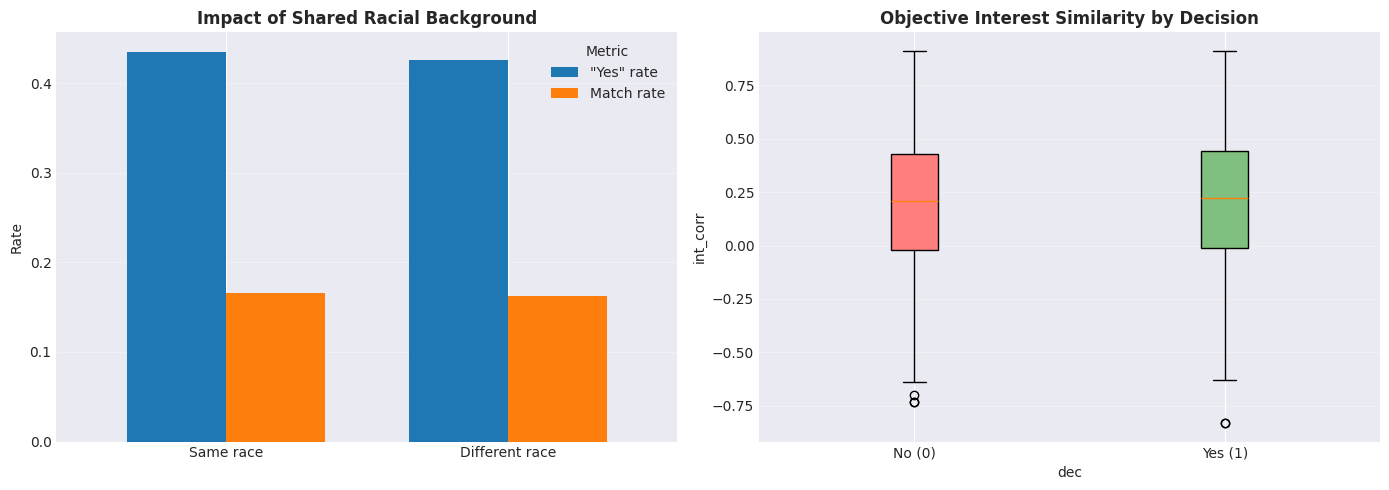

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: yes rate and match rate by same race
race_comparison = pd.DataFrame({
    'Same race': [dec_by_race.get(1, 0), match_by_race.get(1, 0)],
    'Different race': [dec_by_race.get(0, 0), match_by_race.get(0, 0)]
}, index=['"Yes" rate', 'Match rate'])

race_comparison.T.plot(kind='bar', ax=axes[0], width=0.7)
axes[0].set_title('Impact of Shared Racial Background', fontweight='bold')
axes[0].set_ylabel('Rate')
axes[0].set_xlabel('')
axes[0].set_xticklabels(['Same race', 'Different race'], rotation=0)
axes[0].legend(title='Metric')
axes[0].grid(axis='y', alpha=0.3)

# Boxplot: objective interest similarity by decision
df_with_int_corr = df[df['int_corr'].notna()]

group_no = df_with_int_corr[df_with_int_corr['dec'] == 0]['int_corr'].dropna()
group_yes = df_with_int_corr[df_with_int_corr['dec'] == 1]['int_corr'].dropna()
bp = axes[1].boxplot([group_no, group_yes], tick_labels=['No (0)', 'Yes (1)'], patch_artist=True)
bp['boxes'][0].set_facecolor('#ff7f7f')
bp['boxes'][1].set_facecolor('#7fbf7f')
axes[1].set_xlabel('dec')
axes[1].set_ylabel('int_corr')
axes[1].set_title('Objective Interest Similarity by Decision', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/08_race_shared_interests.png', dpi=150, bbox_inches='tight')
plt.show()

### Expected output

![Bar chart: same vs different race and interest correlation heatmap](plots/08_race_shared_interests.png)

Sharing a racial background has virtually no effect on outcomes: the match rate is 16.6% for same-race pairs versus 16.3% for cross-race pairs — a gap of just 0.4 percentage points. The "yes" rate difference is equally negligible (43.5% vs 42.6%). Racial homogamy is not a meaningful predictor of romantic interest in this dataset.

Objective interest similarity (`int_corr`, computed from pre-event questionnaires) correlates with the "yes" decision at only r = 0.013 — statistically close to zero. However, **perceived** shared interests (`shar`, rated during the date) correlate at r = 0.390, making it one of the strongest individual predictors.

*Note: these correlations are computed at the encounter level (6,872 rows); since each participant contributes multiple encounters, observations are not independent. The coefficients describe association strength within the dataset but should not be interpreted as formal inferential tests.*

---
## Q4: Can People Accurately Predict Their Own Perceived Value in the Dating Market?

In [26]:
# Aggregate by participant
self_perception = df.groupby('iid').agg({
    'attr3_1': 'first',   # Self-evaluation
    'sinc3_1': 'first',
    'intel3_1': 'first',
    'fun3_1': 'first',
    'amb3_1': 'first',
    'attr5_1': 'first',   # How I think others see me
    'sinc5_1': 'first',
    'intel5_1': 'first',
    'fun5_1': 'first',
    'amb5_1': 'first',
    'attr_o': 'mean',     # Average ratings received from partners
    'sinc_o': 'mean',
    'intel_o': 'mean',
    'fun_o': 'mean',
    'amb_o': 'mean',
    'shar_o': 'mean',
    'gender': 'first'
}).reset_index()

print(f"Number of participants: {len(self_perception):,}")

Number of participants: 455


In [27]:
# Attractiveness comparison
attractiveness_comparison = self_perception[['attr3_1', 'attr5_1', 'attr_o']].dropna()

print("Attractiveness — Descriptive statistics:\n")
print(attractiveness_comparison.describe().round(2))

print("\nMeans:")
print(f"Self-evaluation (attr3_1):         {attractiveness_comparison['attr3_1'].mean():.2f}")
print(f"Perceived by others (attr5_1):     {attractiveness_comparison['attr5_1'].mean():.2f}")
print(f"Actual partner ratings (attr_o):   {attractiveness_comparison['attr_o'].mean():.2f}")

Attractiveness — Descriptive statistics:

       attr3_1  attr5_1  attr_o
count   232.00   232.00  232.00
mean      6.98     6.86    6.10
std       1.41     1.59    1.19
min       2.00     2.00    2.33
25%       6.00     6.00    5.32
50%       7.00     7.00    6.14
75%       8.00     8.00    7.00
max      10.00    10.00    8.50

Means:
Self-evaluation (attr3_1):         6.98
Perceived by others (attr5_1):     6.86
Actual partner ratings (attr_o):   6.10


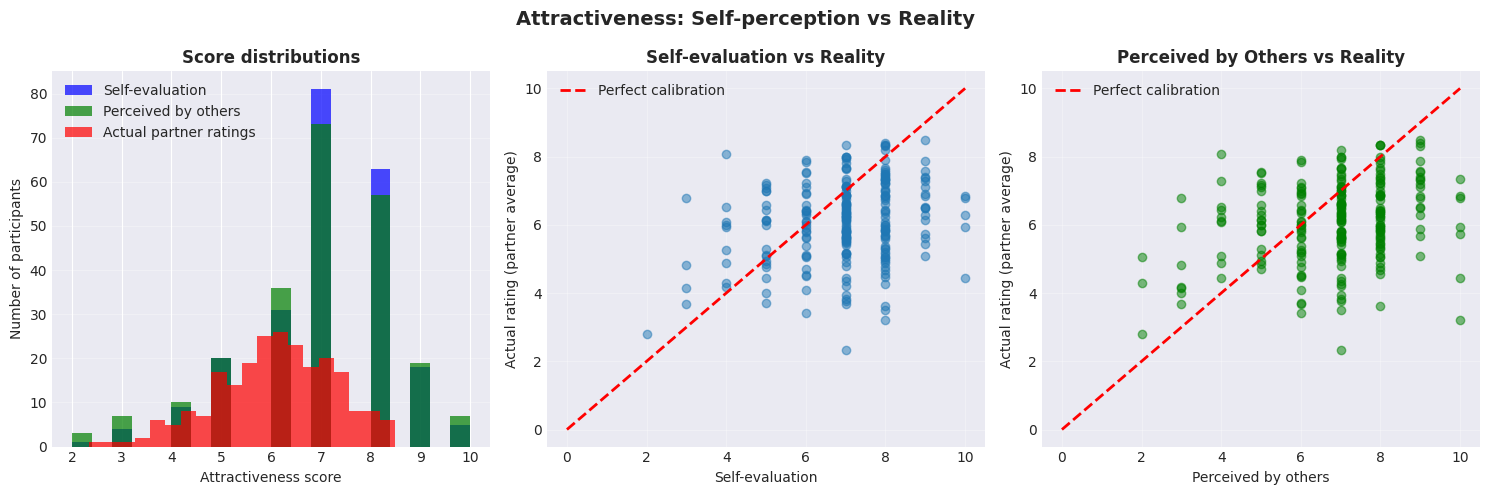

In [28]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Distributions
axes[0].hist(attractiveness_comparison['attr3_1'], bins=20, alpha=0.7, label='Self-evaluation', color='blue')
axes[0].hist(attractiveness_comparison['attr5_1'], bins=20, alpha=0.7, label='Perceived by others', color='green')
axes[0].hist(attractiveness_comparison['attr_o'], bins=20, alpha=0.7, label='Actual partner ratings', color='red')
axes[0].set_xlabel('Attractiveness score')
axes[0].set_ylabel('Number of participants')
axes[0].set_title('Score distributions', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Scatter: self-evaluation vs actual
axes[1].scatter(attractiveness_comparison['attr3_1'], attractiveness_comparison['attr_o'], alpha=0.5)
axes[1].plot([0, 10], [0, 10], 'r--', linewidth=2, label='Perfect calibration')
axes[1].set_xlabel('Self-evaluation')
axes[1].set_ylabel('Actual rating (partner average)')
axes[1].set_title('Self-evaluation vs Reality', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Scatter: perceived-by-others vs actual
axes[2].scatter(attractiveness_comparison['attr5_1'], attractiveness_comparison['attr_o'], alpha=0.5, color='green')
axes[2].plot([0, 10], [0, 10], 'r--', linewidth=2, label='Perfect calibration')
axes[2].set_xlabel('Perceived by others')
axes[2].set_ylabel('Actual rating (partner average)')
axes[2].set_title('Perceived by Others vs Reality', fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Attractiveness: Self-perception vs Reality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/09_self_perception_attractiveness.png', dpi=150, bbox_inches='tight')
plt.show()

### Expected output

![Attractiveness histograms and scatter plots](plots/09_self_perception_attractiveness.png)

- Self-assessed attractiveness distributions are roughly normal, centered around 6-7 on a 10-point scale
- Weak correlation between self-assessment and partner ratings, suggesting limited self-awareness accuracy

In [29]:
# Correlations
print("\nCorrelations with actual partner ratings:\n")
print(f"Self-evaluation:       {attractiveness_comparison['attr3_1'].corr(attractiveness_comparison['attr_o']):.3f}")
print(f"Perceived by others:   {attractiveness_comparison['attr5_1'].corr(attractiveness_comparison['attr_o']):.3f}")


Correlations with actual partner ratings:

Self-evaluation:       0.247
Perceived by others:   0.271


In [30]:
# All attributes comparison
attr_self_cols = ['attr3_1', 'sinc3_1', 'intel3_1', 'fun3_1', 'amb3_1']
attr_perceived_cols = ['attr5_1', 'sinc5_1', 'intel5_1', 'fun5_1', 'amb5_1']
attr_real_cols = ['attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o']

n_self = self_perception[attr_self_cols].dropna(how='all').shape[0]
n_actual = self_perception[attr_real_cols].dropna(how='all').shape[0]

all_attrs_comparison = pd.DataFrame({
    f'Self-evaluation (n={n_self})': self_perception[attr_self_cols].mean().values,
    f'Perceived by others (n={n_self})': self_perception[attr_perceived_cols].mean().values,
    f'Actual partner ratings (n={n_actual})': self_perception[attr_real_cols].mean().values
}, index=['Attractiveness', 'Sincerity', 'Intelligence', 'Fun', 'Ambition'])

print("\nMeans by attribute:\n")
print(all_attrs_comparison.round(2))
print(f"\nNote: Self-evaluation and perceived-by-others data are available for {n_self} participants (Time 1 survey), while partner ratings cover all {n_actual} participants who received at least one rating.")


Means by attribute:

                Self-evaluation (n=446)  Perceived by others (n=446)  \
Attractiveness                     7.06                         6.86   
Sincerity                          8.28                         7.91   
Intelligence                       8.40                         8.27   
Fun                                7.66                         7.28   
Ambition                           7.55                         7.56   

                Actual partner ratings (n=455)  
Attractiveness                            6.18  
Sincerity                                 7.21  
Intelligence                              7.43  
Fun                                       6.43  
Ambition                                  6.86  

Note: Self-evaluation and perceived-by-others data are available for 446 participants (Time 1 survey), while partner ratings cover all 455 participants who received at least one rating.


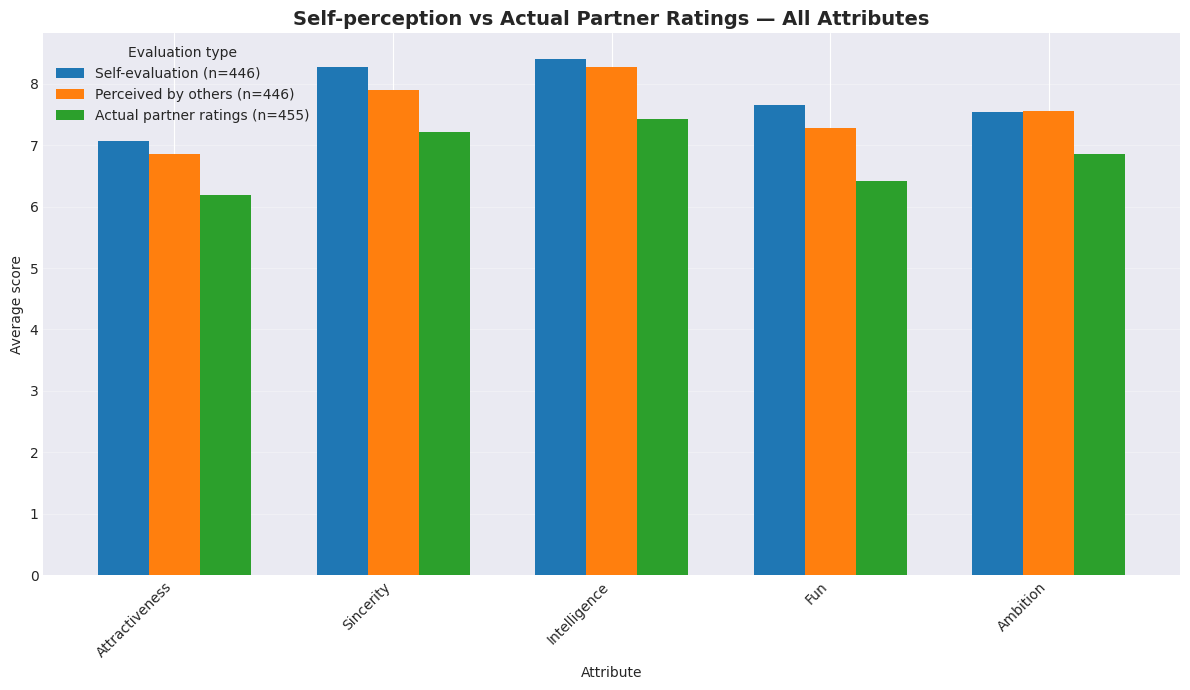

In [31]:
# Visualization: all attributes
all_attrs_comparison.plot(kind='bar', figsize=(12, 7), width=0.7)
plt.title('Self-perception vs Actual Partner Ratings — All Attributes', fontsize=14, fontweight='bold')
plt.ylabel('Average score')
plt.xlabel('Attribute')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Evaluation type')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/10_self_vs_partner_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

### Expected output

![Bar chart: self-perception vs actual partner ratings](plots/10_self_vs_partner_ratings.png)

**Note on sample size:** Self-assessment data (`attr3_1`) is available for ~446 of 455 unique participants (~98%). The table headers reflect this: n=446 for self-evaluation and perceived-by-others columns, n=455 for actual partner ratings. Data availability is nearly complete — no major coverage caveat applies for the per-attribute means.

**Note on the bivariate analysis (n = 232):** The scatter plots and the cited correlations (r = 0.247 self-evaluation vs partner; r = 0.271 perceived-by-others vs partner) are computed on the **n = 232** subset of participants with non-missing values across all three columns simultaneously (`attr3_1`, `attr5_1`, `attr_o`), via row-wise `dropna`. We chose row-wise dropna over imputation because self-prediction is a strict 3-way relationship between self-evaluation, perceived-by-others, and partner-given ratings — imputing any of the three would fabricate the very link we are trying to measure, and median or mean imputation would compress variance and bias correlations toward zero. Row-wise dropna preserves the natural co-occurrence structure of complete responses; the trade-off (n = 232 vs n = 455) is acceptable here because the research question is correlational, not population-mean estimation.

Across all attributes, participants **systematically overestimate** how partners will rate them. The gaps between self-evaluation and actual partner ratings are: Fun +1.23, Sincerity +1.07, Intelligence +0.97, Attractiveness +0.88, Ambition +0.69. **Fun** shows the largest self-inflation, suggesting people believe they come across as more entertaining than they actually do in a 4-minute speed date.

Self-evaluation correlates only weakly with actual partner ratings for attractiveness (r = 0.247), and the "how others see me" estimate is barely better (r = 0.271). People have **poor calibration** about their dating market value — they know roughly whether they are above or below average, but cannot predict their precise score with any accuracy. Most data points cluster **above** the y = x diagonal in the scatter plots, confirming systematic overconfidence.

---
## Q5: Is It Better to Be Someone's First or Last Speed Date of the Night?

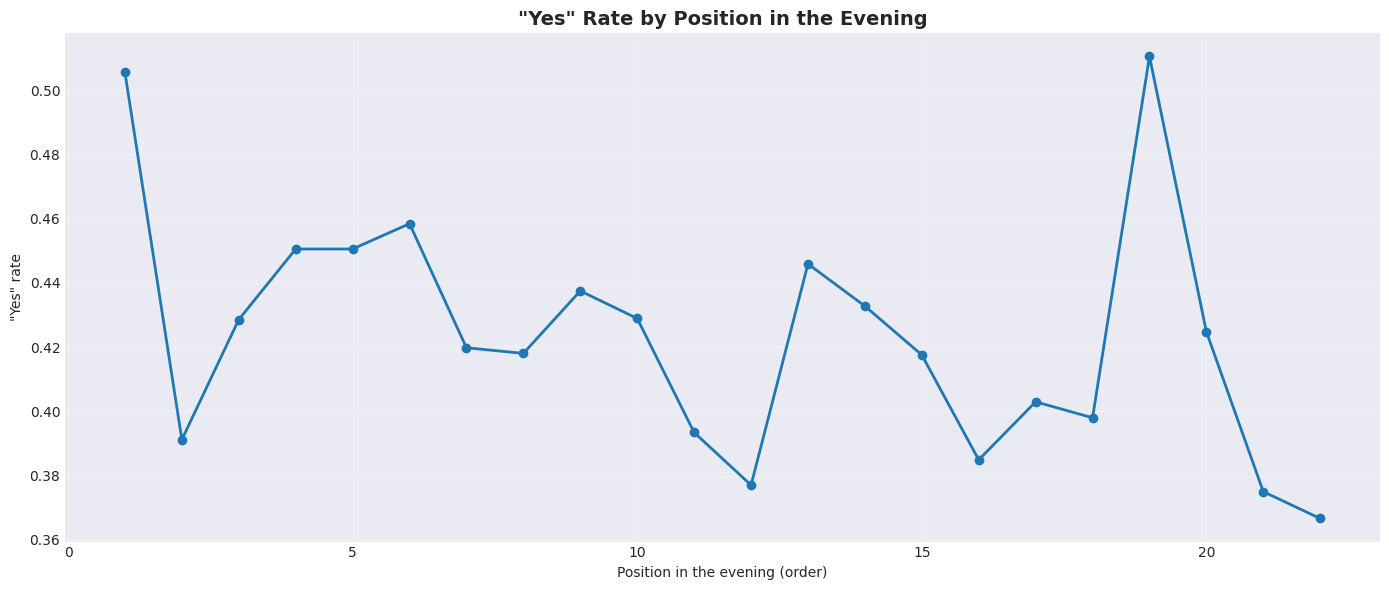

In [32]:
# "Yes" rate by position in the evening
dec_by_order = df.groupby('order')['dec'].mean()

fig, ax = plt.subplots(figsize=(14, 6))
dec_by_order.plot(kind='line', ax=ax, marker='o', linewidth=2, markersize=6)
ax.set_title('"Yes" Rate by Position in the Evening', fontsize=14, fontweight='bold')
ax.set_xlabel('Position in the evening (order)')
ax.set_ylabel('"Yes" rate')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/11_yes_rate_by_position.png', dpi=150, bbox_inches='tight')
plt.show()

### Expected output

![Line chart: yes rate by position in the evening](plots/11_yes_rate_by_position.png)

The line chart reveals a **mildly declining trend** with noise at higher positions (where sample sizes are small). The first few positions show slightly higher "yes" rates, consistent with a weak fatigue effect. There is no U-curve, arguing against a strong serial position memory effect.

In [33]:
# Compare first third vs last third of the evening
max_order_global = df['order'].max()
first_third = df[df['order'] <= max_order_global / 3]
last_third = df[df['order'] >= 2 * max_order_global / 3]

print(f"First third (order <= {max_order_global/3:.0f}):")
print(f'  "Yes" rate : {first_third["dec"].mean():.3f}')
print(f"  Match rate : {first_third['match'].mean():.3f}")

print(f"\nLast third (order >= {2*max_order_global/3:.0f}):")
print(f'  "Yes" rate : {last_third["dec"].mean():.3f}')
print(f"  Match rate : {last_third['match'].mean():.3f}")

print('\nDifference (last - first):')
print(f'  "yes" : {last_third["dec"].mean() - first_third["dec"].mean():.3f}')
print(f"  match : {last_third['match'].mean() - first_third['match'].mean():.3f}")

# Participant-level sign test: does each person say "yes" more in the first
# or last third of their encounters?
max_order_per_iid = df.groupby('iid')['order'].transform('max')
first_mask = df['order'] <= max_order_per_iid / 3
last_mask = df['order'] >= 2 * max_order_per_iid / 3

first_rates = df[first_mask].groupby('iid')['dec'].mean()
last_rates = df[last_mask].groupby('iid')['dec'].mean()
both = pd.DataFrame({'first': first_rates, 'last': last_rates}).dropna()

n_prefer_first = (both['first'] > both['last']).sum()
n_prefer_last = (both['last'] > both['first']).sum()
n_tied = (both['first'] == both['last']).sum()

print(f"\nParticipants with data in both thirds: {len(both)}")
print(f"  Prefer first third:  {n_prefer_first} ({100*n_prefer_first/len(both):.1f}%)")
print(f"  Prefer last third:   {n_prefer_last} ({100*n_prefer_last/len(both):.1f}%)")
print(f"  Tied:                {n_tied} ({100*n_tied/len(both):.1f}%)")

# Chi-square goodness of fit (excluding ties)
chi2, p = stats.chisquare([n_prefer_first, n_prefer_last])
print("\nChi-square goodness of fit (first vs last, excluding ties):")
print(f"  chi2 = {chi2:.3f}, p = {p:.4f}")

First third (order <= 7):
  "Yes" rate : 0.444
  Match rate : 0.173

Last third (order >= 15):
  "Yes" rate : 0.413
  Match rate : 0.146

Difference (last - first):
  "yes" : -0.030
  match : -0.027

Participants with data in both thirds: 455
  Prefer first third:  214 (47.0%)
  Prefer last third:   180 (39.6%)
  Tied:                61 (13.4%)

Chi-square goodness of fit (first vs last, excluding ties):
  chi2 = 2.934, p = 0.0867


First-third encounters produce a 44.4% "yes" rate and 17.3% match rate, versus 41.3% and 14.6% for last-third — a gap of **−3.0 pp on "yes"** and **−2.7 pp on matches**. While modest, the direction is consistent: being encountered early improves both the chance of a "yes" and the chance of a mutual match.

Men mean 'yes' rate (across positions):   0.474
Women mean 'yes' rate (across positions): 0.371


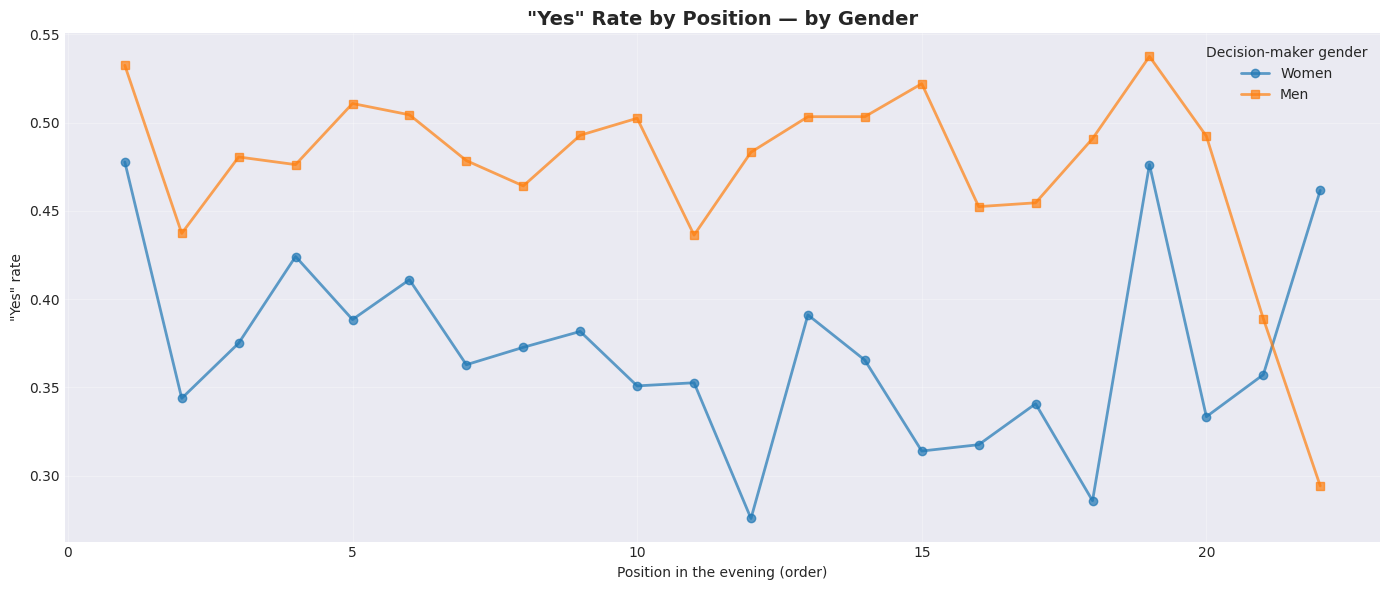

In [34]:
# "Yes" rate by position, split by gender
women_by_order = df[df['gender'] == 0].groupby('order')['dec'].mean()
men_by_order = df[df['gender'] == 1].groupby('order')['dec'].mean()

print(f"Men mean 'yes' rate (across positions):   {men_by_order.mean():.3f}")
print(f"Women mean 'yes' rate (across positions): {women_by_order.mean():.3f}")

fig, ax = plt.subplots(figsize=(14, 6))
women_by_order.plot(kind='line', ax=ax, marker='o', linewidth=2, label='Women', alpha=0.7)
men_by_order.plot(kind='line', ax=ax, marker='s', linewidth=2, label='Men', alpha=0.7)
ax.set_title('"Yes" Rate by Position — by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Position in the evening (order)')
ax.set_ylabel('"Yes" rate')
ax.legend(title='Decision-maker gender')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/12_yes_rate_position_gender.png', dpi=150, bbox_inches='tight')
plt.show()

### Expected output

![Line chart: yes rate by position, split by gender](plots/12_yes_rate_position_gender.png)

Men maintain a consistently higher "yes" rate across all positions than women (men: 47.4%, women: 37.1% — unweighted mean of per-position yes-rates), reflecting gender asymmetry in selectivity. **Women's "yes" rate shows a more pronounced decline** with position, suggesting the position effect is stronger for female decision-makers. Being a woman's first date of the night matters more than being a man's first.

**Answer: A weak ordering effect exists, but it does not reach statistical significance at the conventional threshold.** To respect statistical independence (each participant contributes ~15 encounters), we aggregate at the participant level: for each person, we compare the "yes" rate in their first third vs. last third of encounters, then count how many prefer each. Among the 455 participants with data in both thirds, 214 (47.0%) had a higher "yes" rate in the first third, 180 (39.6%) in the last third, and 61 (13.4%) were tied. The chi-square test does not reach significance at the conventional 0.05 level (chi2 = 2.934, p = 0.087). The tendency — more participants favoring earlier positions — is observed but not statistically confirmed. The mechanism — fatigue vs. serial-position memory — cannot be determined from this data alone.

---
## Situational Factors

Beyond individual attributes, situational context shapes speed-dating outcomes.

### Prior Acquaintance (Mere-Exposure Effect)

The `met` variable indicates whether a pair had already met before the event (1 = yes, 2 = no).

Prior acquaintance — yes rate and match rate:

               yes_rate  match_rate     n
met                                      
Already met       0.588       0.384   318
First meeting     0.429       0.166  3206


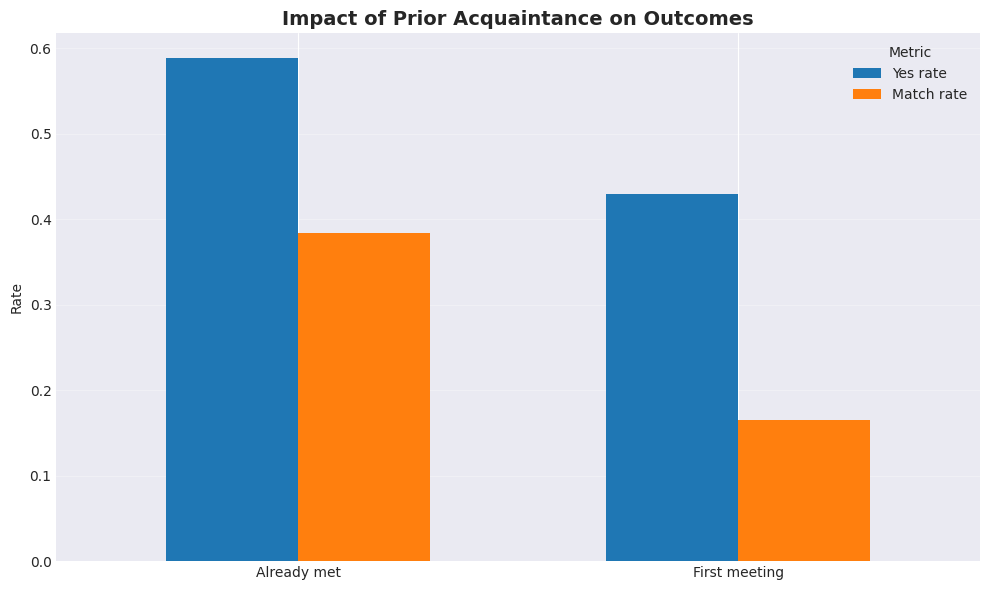

In [35]:
met_labels = {1: "Already met", 2: "First meeting"}
met_stats = (
    df[df["met"].isin([1, 2])]
    .groupby("met")
    .agg(yes_rate=("dec", "mean"), match_rate=("match", "mean"), n=("dec", "count"))
)
met_stats.index = met_stats.index.map(met_labels)

print("Prior acquaintance — yes rate and match rate:\n")
print(met_stats.round(3))

fig, ax = plt.subplots(figsize=(10, 6))
met_stats[["yes_rate", "match_rate"]].plot(kind="bar", ax=ax, width=0.6)
ax.set_title("Impact of Prior Acquaintance on Outcomes", fontsize=14, fontweight="bold")
ax.set_ylabel("Rate")
ax.set_xlabel("")
ax.set_xticklabels(met_stats.index, rotation=0)
ax.legend(["Yes rate", "Match rate"], title="Metric")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig('plots/13_mere_exposure.png', dpi=150, bbox_inches='tight')
plt.show()

### Expected output

![Bar chart: already met vs first meeting impact](plots/13_mere_exposure.png)

- **Prior acquaintance boosts the "yes" rate by ~16 pp** (from ~43% to ~59%), making it the strongest situational factor in the dataset.
- **Match rate is 2.3x higher** for already-met pairs (38.4% vs 16.6%), because familiarity increases the probability that *both* partners say yes.
- This aligns with the **mere-exposure effect** (Zajonc, 1968): repeated exposure to a stimulus increases liking, even without meaningful interaction.
- **Caveat:** the prior-acquaintance sample is small (n ~ 318 vs 3,206 first meetings), and self-selection bias is likely — people who already met may share social circles, pre-existing affinity, or mutual friends who encouraged attendance.

### Wave Size and the Paradox of Choice

We use Spearman rank correlation rather than Pearson because the sample is small (n = 21 waves), normality cannot be reliably assessed, and the relationship between wave size and selectivity may not be strictly linear.

Spearman correlation: rho = -0.393, p = 0.0778
Number of waves: 21


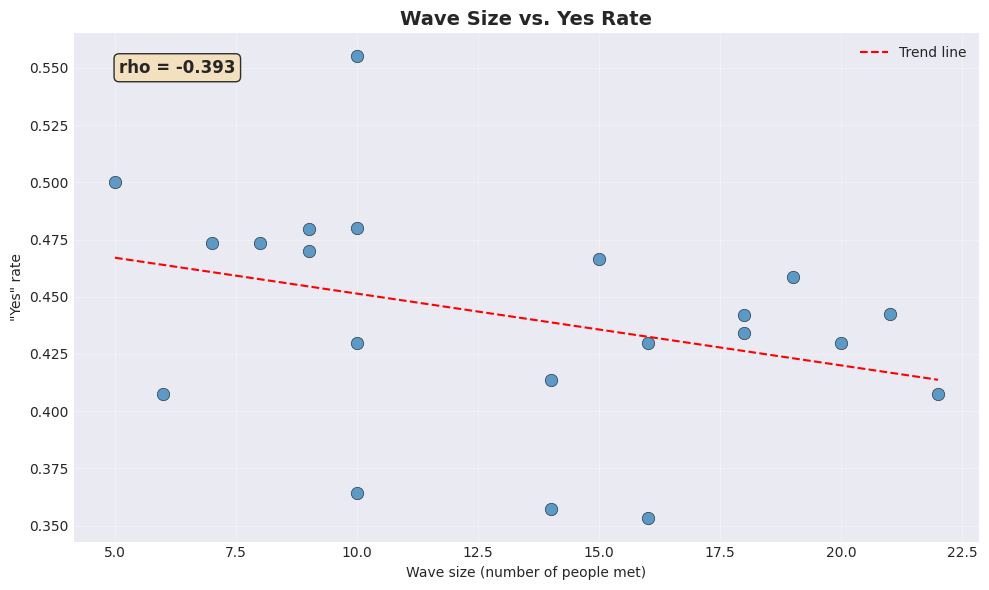

In [36]:
# Wave-level aggregation: size (round) and yes rate
wave_stats = df.groupby("wave").agg(
    wave_size=("round", "first"),
    yes_rate=("dec", "mean"),
).reset_index()

rho, p = stats.spearmanr(wave_stats["wave_size"], wave_stats["yes_rate"])
print(f"Spearman correlation: rho = {rho:.3f}, p = {p:.4f}")
print(f"Number of waves: {len(wave_stats)}")

# Scatter plot with trend line
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(wave_stats["wave_size"], wave_stats["yes_rate"], s=80, alpha=0.7, edgecolors="k", linewidths=0.5)

coeffs = np.polyfit(wave_stats["wave_size"], wave_stats["yes_rate"], 1)
trend_fn = np.poly1d(coeffs)
x_range = np.linspace(wave_stats["wave_size"].min(), wave_stats["wave_size"].max(), 50)
ax.plot(x_range, trend_fn(x_range), "--", color="red", linewidth=1.5, label="Trend line")

ax.annotate(f"rho = {rho:.3f}", xy=(0.05, 0.95), xycoords="axes fraction",
            fontsize=12, fontweight="bold", verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.8))
ax.set_title("Wave Size vs. Yes Rate", fontsize=14, fontweight="bold")
ax.set_xlabel("Wave size (number of people met)")
ax.set_ylabel('"Yes" rate')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/14_paradox_of_choice.png', dpi=150, bbox_inches='tight')
plt.show()

### Expected output

![Scatter plot: wave size vs yes rate with trend line](plots/14_paradox_of_choice.png)

- **Spearman rank correlation: rho = -0.393, p = 0.078 (n = 21 waves)** — a weak-to-moderate negative trend between wave size and "yes" rate: participants become more selective when they meet more people in a single event.
- **Why Spearman over Pearson:** with n = 21, normality cannot be reliably assessed (Shapiro-Wilk is underpowered at this sample size), the relationship between wave size and selectivity may be non-linear, and Spearman operates on ranks — making it robust to outliers and free of the linearity assumption.
- This is consistent with the **paradox of choice** (Schwartz, 2004): an abundance of options increases cognitive load and raises the bar for saying "yes."
- **Significance:** not significant at α = 0.05, but it does fall below α = 0.10 — a suggestive trend rather than a conclusive one, with statistical power further limited by the n = 21 sample.
- Larger waves may also differ on other confounds (venue capacity, time of year, participant demographics), so wave size alone should not be interpreted as a causal driver of selectivity.

---
## Supporting Analysis: Correlation Matrices

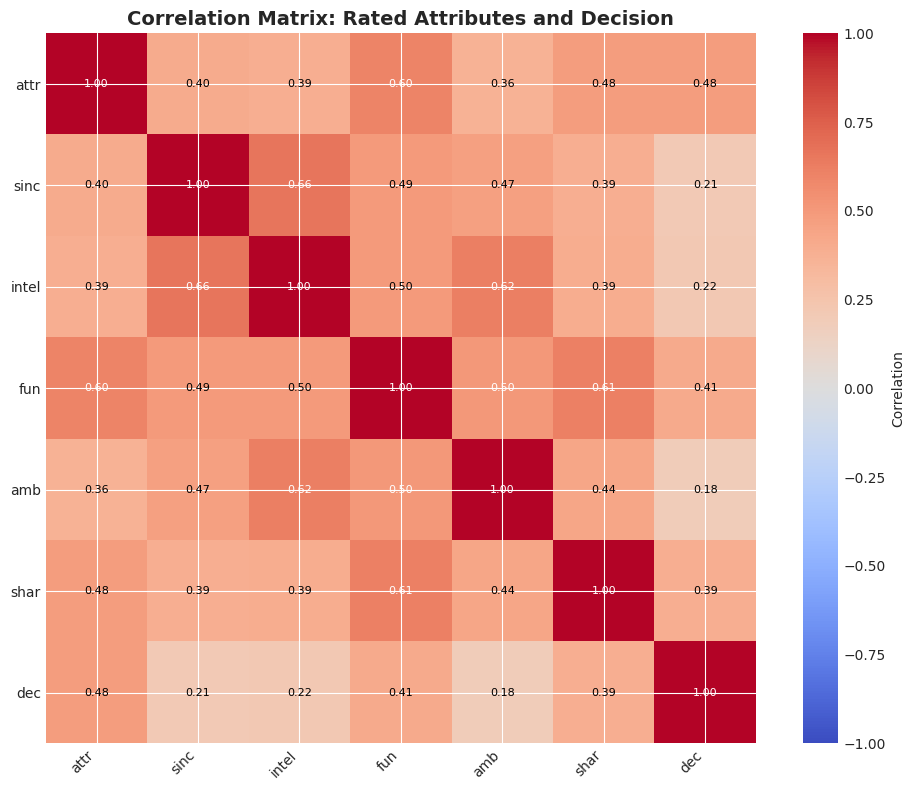

In [37]:
# Correlation matrix: rated attributes vs decision
corr_matrix = df[attr_rating_cols + ['dec']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='equal')
# Annotations
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=8)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
plt.colorbar(im, label='Correlation')
ax.set_title('Correlation Matrix: Rated Attributes and Decision', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/15_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Expected output

![Heatmap: attribute ratings vs decision correlation](plots/15_correlation_matrix.png)

- A halo effect is visible: attributes are significantly inter-correlated (a person rated attractive also scores higher on fun, intelligence, sincerity)
- Sincerity and ambition are the weakest predictors of decision (r ~ 0.18-0.22)

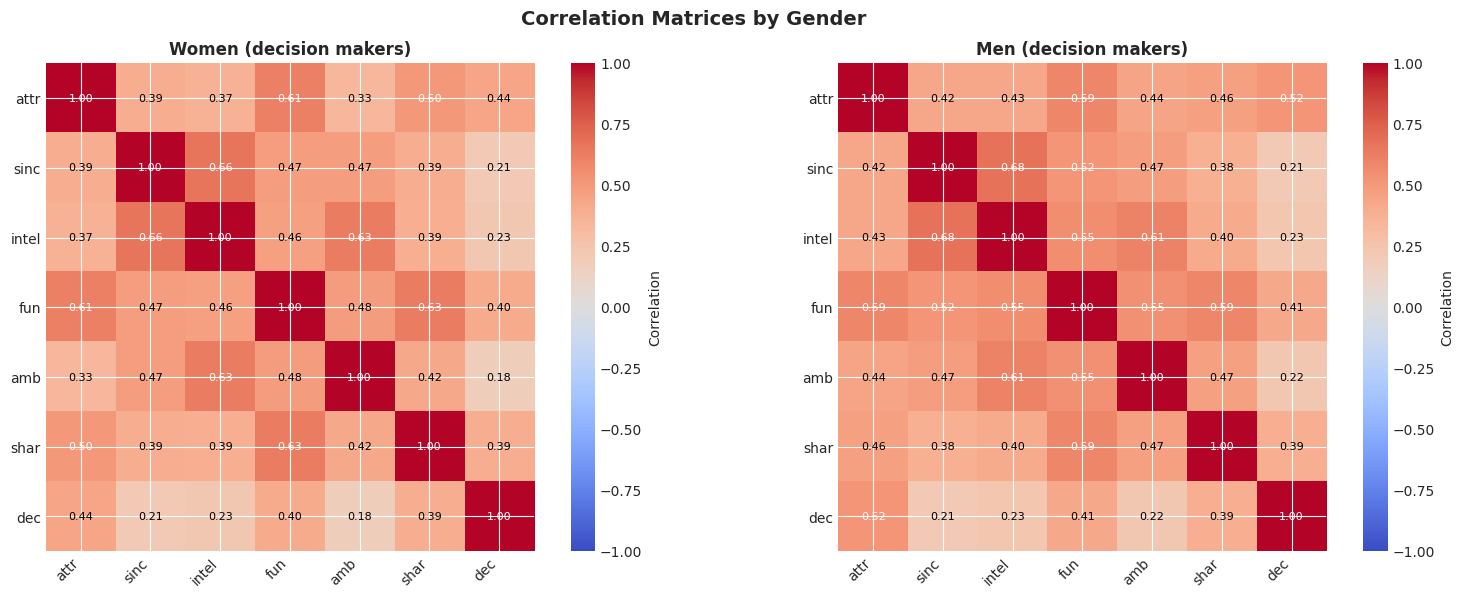

In [38]:
# Separate matrices by gender
women_corr_matrix = df[df['gender'] == 0][attr_rating_cols + ['dec']].corr()
men_corr_matrix = df[df['gender'] == 1][attr_rating_cols + ['dec']].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im0 = axes[0].imshow(women_corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='equal')
for i in range(women_corr_matrix.shape[0]):
    for j in range(women_corr_matrix.shape[1]):
        val = women_corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        axes[0].text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=8)
axes[0].set_xticks(range(len(women_corr_matrix.columns)))
axes[0].set_xticklabels(women_corr_matrix.columns, rotation=45, ha='right')
axes[0].set_yticks(range(len(women_corr_matrix.index)))
axes[0].set_yticklabels(women_corr_matrix.index)
plt.colorbar(im0, ax=axes[0], label='Correlation')
axes[0].set_title('Women (decision makers)', fontweight='bold')

im1 = axes[1].imshow(men_corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='equal')
for i in range(men_corr_matrix.shape[0]):
    for j in range(men_corr_matrix.shape[1]):
        val = men_corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        axes[1].text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=8)
axes[1].set_xticks(range(len(men_corr_matrix.columns)))
axes[1].set_xticklabels(men_corr_matrix.columns, rotation=45, ha='right')
axes[1].set_yticks(range(len(men_corr_matrix.index)))
axes[1].set_yticklabels(men_corr_matrix.index)
plt.colorbar(im1, ax=axes[1], label='Correlation')
axes[1].set_title('Men (decision makers)', fontweight='bold')

plt.suptitle('Correlation Matrices by Gender', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/16_correlation_matrix_gender.png', dpi=150, bbox_inches='tight')
plt.show()

### Expected output

![Two heatmaps: correlation by gender](plots/16_correlation_matrix_gender.png)

The correlation matrix reveals a **halo effect**: attributes are significantly inter-correlated — a participant rated as attractive tends to be rated higher on fun, intelligence, and sincerity as well. The gender-split matrices confirm the pattern is consistent, with men's decisions showing a slightly stronger attractiveness signal (r = 0.517 vs 0.436 for women). Sincerity and ambition are the weakest predictors for both genders (r ≈ 0.18–0.22).

---
## Demographic Factors

Beyond attributes and preferences, demographic characteristics may influence matching outcomes.

### Same Field of Study

In [39]:
# Build partner field_cd lookup (one row per iid)
partner_field_lookup = (
    df[['iid', 'field_cd']]
    .drop_duplicates('iid')
    .rename(columns={'iid': 'pid', 'field_cd': 'field_cd_partner'})
)

df = pd.merge(df, partner_field_lookup, on='pid', how='left')

# Propagate NA when either participant has no field_cd data
_mask = df['field_cd'].isna() | df['field_cd_partner'].isna()
_same = (df['field_cd'] == df['field_cd_partner']).astype('Int64')
_same[_mask] = pd.NA
df['same_field'] = _same

n_valid = df['same_field'].notna().sum()
n_same = (df['same_field'] == 1).sum()
print(f"Same field pairs : {n_same} / {n_valid} valid ({n_same/n_valid:.1%})")
print(f"Coverage : {n_valid}/{len(df)} rows with known field ({n_valid/len(df):.1%})")
print()

# Match rate by same_field
match_by_same_field = df.groupby('same_field')['match'].mean()
print("Match rate by same_field:")
print(f"  Different field : {match_by_same_field.get(0, float('nan')):.3f}")
print(f"  Same field      : {match_by_same_field.get(1, float('nan')):.3f}")

Same field pairs : 748 / 5644 valid (13.3%)
Coverage : 5644/6872 rows with known field (82.1%)

Match rate by same_field:
  Different field : 0.154
  Same field      : 0.225


- Same-field pairs match at ~22.5% vs ~15.4% for different-field pairs — a 7 pp gap that is the largest demographic effect in this dataset.
- Shared academic background likely signals common interests and values, creating a sense of familiarity that boosts mutual attraction.
- This variable is built via `pd.merge` on `pid` (partner ID), demonstrating feature engineering from relational data.

### Attractiveness by Field of Study

Top 5 most attractive fields:
                                                mean_dec_o    n
field_cd_label                                                 
Medical Science, Pharmaceuticals, and Bio Tech       0.625    9
Law                                                  0.464   38
Business/Econ/Finance                                0.458  109
Social Work                                          0.454   22
Political Science/International Affairs              0.446   40

Bottom 5 least attractive fields:
                             mean_dec_o   n
field_cd_label                             
Education, Academia               0.391  35
Math                              0.385  13
Film                              0.383   7
History/Religion/Philosophy       0.373  14
Engineering                       0.304  47


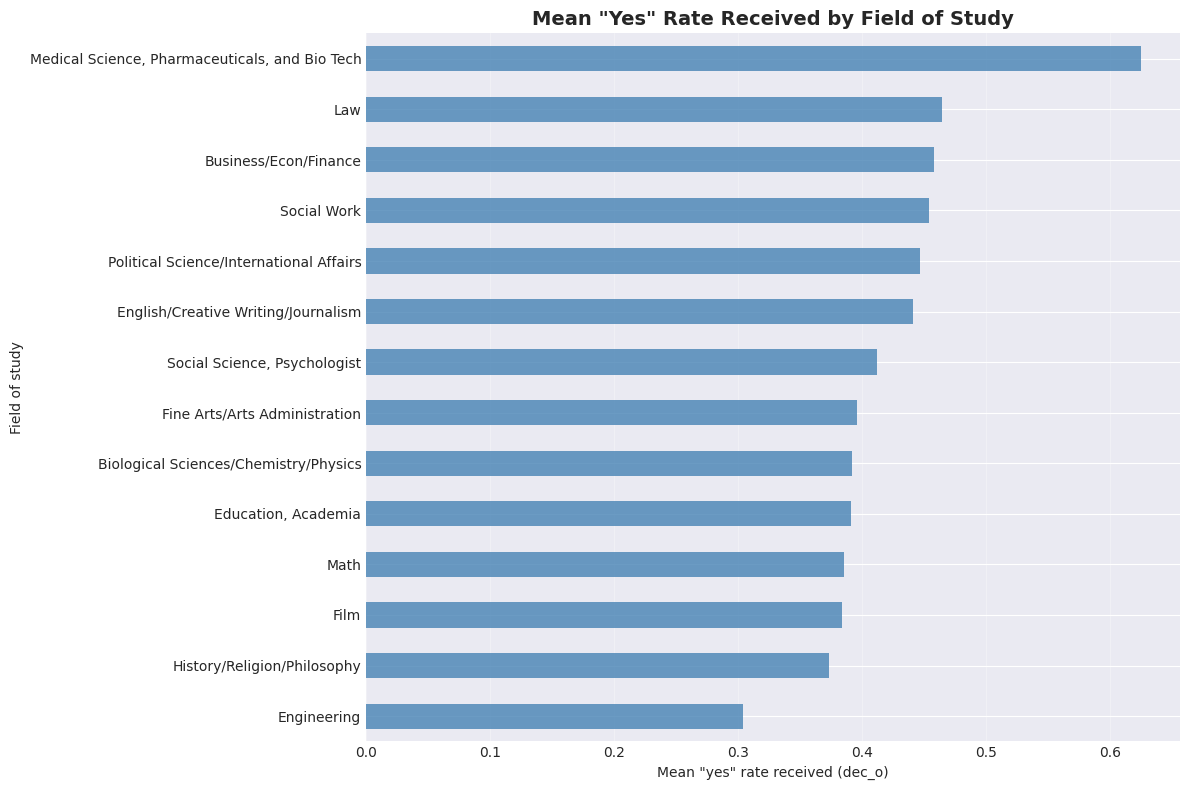

In [40]:
# Map field_cd to readable labels
df['field_cd_label'] = df['field_cd'].map(MAPPINGS['field_cd'])

# Aggregate at participant level: mean dec_o (yes votes received) and field label
participant_field = (
    df.groupby('iid')
    .agg(dec_o=('dec_o', 'mean'), field_cd_label=('field_cd_label', 'first'))
    .reset_index()
)

# Group by field, compute mean attractiveness, filter to fields with >= 5 participants
field_attractiveness = (
    participant_field.groupby('field_cd_label')
    .agg(mean_dec_o=('dec_o', 'mean'), n=('iid', 'count'))
    .query('n >= 5')
    .sort_values('mean_dec_o', ascending=False)
)

print("Top 5 most attractive fields:")
print(field_attractiveness.head(5)[['mean_dec_o', 'n']].round(3).to_string())
print("\nBottom 5 least attractive fields:")
print(field_attractiveness.tail(5)[['mean_dec_o', 'n']].round(3).to_string())

fig, ax = plt.subplots(figsize=(12, 8))
field_attractiveness['mean_dec_o'].sort_values().plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Mean "Yes" Rate Received by Field of Study', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean "yes" rate received (dec_o)')
ax.set_ylabel('Field of study')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/17_field_attractiveness.png', dpi=150, bbox_inches='tight')
plt.show()

df.drop(columns=['field_cd_partner', 'same_field', 'field_cd_label'], inplace=True, errors='ignore')

### Expected output

![Horizontal bar: yes rate received by field of study](plots/17_field_attractiveness.png)

- **Most attractive fields**: Medical Science / Pharmaceuticals / Bio Tech leads at ~62.5% yes received, followed by Law (~46.4%) and Business/Econ/Finance (~45.8%) — fields perceived as high-status or socially desirable.
- **Least attractive field**: Engineering ranks last at ~30.4% yes received.
- **Spread**: The spread between the most and least attractive fields exceeds 30 percentage points.
- **Note**: These rates reflect partner perceptions aggregated across many encounters, not self-assessment. Small-sample fields (n < 5 excluded) should be interpreted with caution; Medical Science in particular has only 9 participants.

---
## Conclusion: What Makes People Want a Second Date?

**Q1 — Least desirable attributes:** Shared Interests and Ambition are the lowest-ranked attributes for both genders, but their order differs: Shared Interests is the lowest for women (12.6 pts), Ambition is the lowest for men (8.7 pts). Men prioritize Attractiveness above all (+9.3 pts vs women); women spread their criteria more evenly, led by Intelligence and Sincerity.

**Q2 — Attractiveness: talk vs. action:** Attractiveness is the top-stated attribute (22.2/100 pts), but its dominance in actual decisions (r = 0.483) far exceeds the modest lead it holds in stated preferences. Intelligence and Sincerity, which participants claim to value highly, rank only 4th and 5th in actual predictive power (r ~ 0.21). The gap between stated and revealed preferences is a textbook social desirability effect.

**Q3 — Interests vs. race:** Shared racial background has virtually no effect (+0.4 pp match rate). Objective interest similarity is equally irrelevant (r = 0.013). What matters is **perceived** shared interests during the date (r = 0.390) — the feeling of connection, not the demographic reality.

**Q4 — Self-prediction:** People systematically overestimate their dating market value across all five attributes measured (biggest gap: Fun, +1.23 pts). Self-evaluation of **attractiveness** correlates only weakly with actual partner ratings (r = 0.247, on n = 232 participants with complete-case data); analogous correlations for sincerity, intelligence, fun, and ambition are not computed in this notebook but are expected to follow the same pattern. Accurate self-assessment in the dating market is rare.

**Q5 — Position effect:** A participant-level analysis shows a trend toward earlier positions yielding higher "yes" rates (47.0% prefer first third vs. 39.6% prefer last third), but the chi-square test does not reach significance (chi2 = 2.934, p = 0.087). The effect is more pronounced for female decision-makers, though it remains statistically inconclusive.

**Situational and contextual factors:** Prior acquaintance produces the strongest situational effect, boosting the "yes" rate by ~16 pp (mere-exposure effect). Larger wave sizes show a suggestive negative correlation with selectivity (Spearman rho = -0.393, p = 0.078, n = 21 waves), consistent with the paradox of choice — not significant at α = 0.05, but it does fall below α = 0.10 (a suggestive trend, with statistical power further limited by the n = 21 sample). Sharing the same field of study produces a +7 pp match rate gap — the largest demographic effect in this dataset, exceeding race or any other background variable. Attractiveness ratings received also vary substantially by field (spread of ~32 pp between top and bottom fields).

**Overall:** The dominant drivers of a second-date decision are physical attractiveness, fun, and the perception of shared interests — regardless of what people claim to value. A halo effect pervades all ratings: a person judged attractive also scores higher on fun, intelligence, and sincerity. Most demographic factors are poor predictors, with same field of study as the notable exception. Situational context matters too — prior familiarity and event size both shape decisions. Stated preferences and self-assessments are systematically miscalibrated, making revealed behavior the only reliable guide to what people actually want.